<span style="color: blue; font-size: 20px; font-weight: bold;">Комментарий ревьюера</span>

<span style="color: blue">Привет, Андрей! Меня зовут Павел Григорьев, и я буду проверять этот проект.<br>Моя основная цель - не указать на совершённые тобой ошибки, а поделиться своим опытом и помочь тебе совершенствоваться как профессионалу.<br>Спасибо за проделанную работу! Предлагаю общаться на «ты».</span>
<details>
	<summary><u>Инструкция по организационным моментам (кликабельно)</u>⤵</summary>
<span style="color: blue">Я буду использовать различные цвета, чтобы было удобнее воспринимать мои комментарии:</span>


---


<span style="color: blue">синий текст - просто текст комментария</span>

<span style="color: green">✔️ и зеленый текст - все отлично</span>

<span style="color: orange">⚠️ и оранжевый текст - сделано все правильно, однако есть рекомендации, на что стоит обратить внимание</span>

<span style="color: red">❌ и красный текст - есть недочеты</span>


</details>    
</br>
<span style="color: blue">Пожалуйста, не удаляй мои комментарии в случае возврата работы, так будет проще разобраться, какие были недочеты, а также сразу увидеть исправленное.</span>

<span style="color: blue">Ответы на мои комментарии лучше тоже помечать.<br>
Например: </span><br><span style="color: purple; font-weight: bold">Комментарий студента</span>

<span style="color: blue; font-weight: bold;">Давай смотреть, что получилось!</span>

## Проект спринта 12. Прогнозирование CTR в рекламных аукционах.

## Цель и задачи.
**Цель:** Увеличение прибыли платформы онлайн-рекламы при помощи улучшения механизма прогнозирования вероятности перехода пользователей по рекламным ссылкам.

### Задачи:
1. Загрузка данных и знакомство с их содержимым.
2. Исследовательский анализ данных.
3. Отбор признаков для задачи машинного обучения.
3. Предобработка данных для машинного обучения.
4. Разработка механизма предсказания оттока клиентов.
    - Обучение и оценка базовых моделей классификации.
    - Подбор гиперпараметров моделей.
    - Калибровка прогнозируемых моделями вероятностей.
    - Финальное обучение моделей и подготовка артефактов.
5. Формулировка выводов, содержащих оценку и анализ результатов обучения моделей.

### Постановка задачи в терминах машинного обучения
- Необходимо решить задачу машинного обучения для предсказания вероятности клика (CTR) на рекламном объявлении на основе предоставленного датасета с признаками и значениями целевой переменной.
- Тип задачи машинного обучения: бинарная классификация.
- Целевая переменная - вероятность клика на рекламной объявлении (CTR).
- Модели машинного обучения - логистическая регрессия и метод опорных векторов (SVM).
- Необходимо откалибровать вероятности, возвращаемые моделями, т.е. обеспечить их соответствие реальной частоте классов.
- Основные метрики - PR-AUC, Log Loss, Brier score. Вспомогательные метрики - Precision, Recall, F1. Метрики для калибровки - ECE, MCE. 
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.
- Для тестовой выборки необходимо выделить 20% измерений из датасета.
- Решение должно быть сохранено в виде готового к промышленной эксплуатации пайплайна.

### Данные

Для анализа поступили данные в формате CSV-файла, который доступен по ссылке [ds_s16_ad_click_dataset](https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv).

- **Период агрегации.** Данные содержат информацию о показе рекламных баннеров и действиях пользователей за фиксированный временной промежуток.
- **Формат данных.** Данные представлены в виде готовой аналитической витрины. Это означает, что для каждого показа рекламного баннера уже рассчитаны и собраны в одну строку все необходимые для моделирования признаки.
- **Структура.** Каждая строка соответствует одному уникальному событию показа рекламы. Все признаки предварительно обработаны и представлены в виде числовых и категориальных значений.
- **Данные анонимизированы.** Датасет прошёл предварительную обработку для обеспечения анонимности и сохранности данных. Например, в признаке `site_category` содержатся такие категории, как `50e219e0` и `3e814130`.

#### **Признаки в датасете**

**Идентификаторы и временные метки:**

- `id` — уникальный идентификатор записи о показе баннера;
- `hour` — час, в который был показан баннер, в формате `YYMMDDHH`.

**Характеристики рекламной площадки ( `Site` ):**

- `site_id` — идентификатор веб-сайта, на котором был показан баннер;
- `site_domain` — домен веб-сайта;
- `site_category` — тематическая категория веб-сайта.

**Характеристики рекламируемого приложения ( `App` ):**

- `app_id` — идентификатор рекламируемого мобильного приложения;
- `app_domain` — домен рекламируемого приложения;
- `app_category` — категория рекламируемого приложения.

**Характеристики устройства и соединения пользователя:**

- `device_id` — идентификатор браузера или устройства;
- `device_ip` — IP-адрес устройства;
- `device_model` — модель устройства;
- `device_type` — тип устройства пользователя: например, смартфон, планшет, ПК;
- `device_conn_type` — тип сетевого соединения устройства: например, Wi-Fi, 3G, 4G.

**Характеристики рекламного баннера и аукциона:**

- `banner_pos` — позиция баннера на веб-странице;
- `C1` — анонимизированный признак, характеризующий контекст показа;
- `C14` — `C21` — группа анонимизированных признаков, описывающих параметры баннера, пользователя или аукциона.

**Машинно-сгенерированные признаки (ML Features):**

- `ml_feature_1`, `ml_feature_3` — `ml_feature_6`, `ml_feature_8` — `ml_feature_10` — числовые признаки, полученные в результате предварительной обработки и генерации новых признаков;
- `ml_feature_2`, `ml_feature_7` — категориальные признаки, полученные в результате предварительной обработки и генерации новых признаков.

**Целевая переменная:**

- `click` — бинарный признак, указывающий, был ли совершён клик по баннеру. `1` — клик был, `0` — клика не было.

# Структура проекта
1. [Подготовка среды и загрузка данных.](#1-подготовка-среды-и-загрузка-данных)
    - [1.1. Подготовка библиотек.](#11-подготовка-библиотек)
    - [1.2. Фиксация константы для воспроизводимости.](#12-фиксация-константы-для-воспроизводимости)
    - [1.3. Загрузка данных.](#13-загрузка-данных)
2. [Исследовательский анализ данных (EDA).](#2-исследовательский-анализ-данных-eda)
    - [2.1. Базовая информация о датасете.](#21-базовая-информация-о-датасете)
    - [2.2. Анализ целевой переменной.](#22-анализ-целевой-переменной)
    - [2.3. Анализ категориальных произнаков.](#23-анализ-категориальных-признаков)
    - [2.4. Анализ числовых признаков.](#24-анализ-числовых-признаков)
    - [2.5. Анализ корреляций.](#25-анализ-корреляций)
    - [2.6. Выводы](#26-выводы)
3. [Разделение данных на выборки.](#3-разделение-данных-на-выборки)
    - [3.1. Разделение данных.](#31-разделение-данных)
    - [3.2. Проверка разделения.](#32-проверка-разделения)
4. [Предобработка данных - построение пайплайнов.](#4-предобработка-данных--построение-пайплайнов)
5. [Отбор признаков.](#5-отбор-признаков)
    - [5.1. Фильтрационные методы.](#51-фильтрационные-методы)
    - [5.2. Отбор при помощи методов-обёрток.](#52-отбор-при-помощи-методов-обёрток)
    - [5.3. Создание финального набора признаков.](#53-создание-финального-набора-признаков)
6. [Обучение базовой модели.](#6-обучение-базовой-модели)
    - [6.1. Обучение `DummyClassifier`.](#61-обучение-dummyclassifier)
    - [6.2. Обучение модели логистической регрессии.](#62-обучение-модели-логистической-регрессии)
    - [6.3. Обучение модели SVM.](#63-обучение-модели-svm)
    - [6.4. Выводы.](#64-выводы)
7. [Подбор гиперпараметров `GridSearch` с кросс-валидацией.](#7-подбор-гиперпараметров-grid-search-с-кросс-валидацией)
    - [7.1. Определение сеток гиперпараметров.](#71-определение-сеток-гиперпараметров)
    - [7.2. Применение `GridSearch`.](#72-применение-gridsearch)
    - [7.3. Вывод](#73-вывод)
8. [Финальная модель.](#8-финальная-модель)
    - [8.1. Обучение финальной модели.](#81-обучение-финальной-модели)
    - [8.2. Подсчет метрик на тестовой выборке.](#82-подсчет-метрик-на-тестовой-выборке)
    - [8.3. Анализ весов модели.](#83-анализ-весов-модели)
9. [Калибровка модели.](#9-калибровка-модели)
    - [9.1. Проверка текущей калибровки.](#91-проверка-текущей-калибровки)
    - [9.2. Применение методов калибровки.](#92-применение-методов-калибровки)
    - [9.3. Сравнение моделей до и после калибровки.](#93-сравнение-моделей-до-и-после-калибровки)
10. [Оценка качества калибровки.](#10-оценка-качества-калибровки) 
    - [10.1. Вычисление метрик калибровки.](#101-вычисление-метрик-калибровки)
    - [10.2. Сравнение моделей до и после калибровки.](#102-сравнение-моделей-до-и-после-калибровки)
    - [10.3. Выводы.](#103-выводы)
11. [Финальный отчет и выводы.](#11-финальный-отчёт-и-выводы)
    - [11.1. Таблицы результатов.](#111-таблицы-результатов)
    - [11.2. Финальные выводы.](#112-финальные-выводы)
    - [11.3. Рекомендации.](#113-рекомендации)
12. [Сохранение модели для продакшена.](#12-сохранение-модели-для-продакшена)
    - [12.1. Сохранение артефактов.](#121-сохранение-артефактов)
    - [12.2. Проверка работоспособности сохраненных артефактов.](#122-проверка-работоспособности-сохраненных-артефактов)

## 1. Подготовка среды и загрузка данных

#### 1.1 Подготовка библиотек

- Установка необходимых пакетов:

In [1]:
%pip install -q numpy==1.23
%pip install -q --upgrade scikit-learn
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2
%pip install -q phik
%pip install -q mlxtend

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\cli\req_command.py", line 96, in wrapper
    return func(self, options, args)
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\commands\install.py", line 392, in run
    requirement_set = resolver.resolve(
        reqs, check_supported_wheels=not options.target_dir
    )
  File "c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 99, in resolve

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


- Импортируем необходимые пакеты:

In [2]:
import pandas as pd
import numpy as np
import phik

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.frozen import FrozenEstimator
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, \
    average_precision_score, log_loss, recall_score, precision_score, brier_score_loss
from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Хорошее оформление импортов! \
Импорты собраны в одной ячейке, разделены на функциональные группы пустой строкой.</font>

#### 1.2 Фиксация константы для воспроизводимости
- Зафиксируем значение `random_state` для воспроизводимости результатов:

In [3]:
RANDOM_SEED=42

#### 1.3 Загрузка данных
- Загрузим данные из датасета и выведем основные сведения о них:

In [4]:
try:
    # Сначала загрузим данныз из локального файла
    df = pd.read_csv("datasets/ds_s16_ad_click_dataset.csv")
except FileNotFoundError:
    # Если файла нет, загружаем по сети
    df = pd.read_csv("https://code.s3.yandex.net/data-scientist/ds_s16_ad_click_dataset.csv")

display(df.info())
display(df.head(10))

initial_count = len(df)

# Посчитаем количество явных дубликатов
dup_columns = df.columns.to_list()
dup_columns.remove('id')
dup_columns.remove('device_id')
dup_count = df[dup_columns].duplicated().sum()
print(f"Количество дубликатов: {dup_count} ({dup_count / initial_count * 100: .2f}%)")
print("\nКоличество уникальных значений по столбцам:")
display(pd.DataFrame(df.nunique()).sort_values(by=0, ascending=False).style.background_gradient(cmap='coolwarm'))

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                50000 non-null  float64
 1   click             50000 non-null  int64  
 2   hour              50000 non-null  int64  
 3   C1                50000 non-null  int64  
 4   banner_pos        50000 non-null  int64  
 5   site_id           50000 non-null  str    
 6   site_domain       50000 non-null  str    
 7   site_category     50000 non-null  str    
 8   app_id            50000 non-null  str    
 9   app_domain        50000 non-null  str    
 10  app_category      50000 non-null  str    
 11  device_id         50000 non-null  str    
 12  device_ip         50000 non-null  str    
 13  device_model      50000 non-null  str    
 14  device_type       50000 non-null  int64  
 15  device_conn_type  50000 non-null  int64  
 16  C14               50000 non-null  int64  
 17  C15 

None

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,ml_feature_1,ml_feature_2,ml_feature_3,ml_feature_4,ml_feature_5,ml_feature_6,ml_feature_7,ml_feature_8,ml_feature_9,ml_feature_10
0,1.005263e+19,1,14102100,1005,1,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-0.996823,A,0.666588,0,0.817292,0.993275,Z,-0.619959,0.433666,0.274038
1,1.010597e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.391309,C,5.146789,1,-0.883865,-0.825722,X,0.576526,-0.318558,-0.132851
2,1.012048e+19,0,14102100,1005,0,d9750ee7,98572c79,f028772b,ecad2386,7801e8d9,...,-2.112732,D,7.169348,0,-0.859440,-0.338365,Y,-0.440047,-0.345412,0.340487
3,1.021995e+18,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,39cfef32,d9b5648e,...,0.332707,A,-0.290708,1,0.062795,0.062934,Y,0.551982,0.733382,-0.198542
4,1.023455e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1.166623,A,6.319134,1,-0.675276,0.797144,X,0.640827,0.297955,-0.136909
5,1.037910e+19,1,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-0.386621,D,-2.561220,1,-0.327084,0.997424,Y,-0.718630,0.063355,0.118050
6,1.046962e+19,0,14102100,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,...,-1.029484,B,0.616779,0,-0.088135,-0.484160,Y,0.390766,0.399371,0.278207
7,1.048718e+19,0,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,fbbccc58,2347f47a,...,-1.412949,A,0.667451,0,0.010914,-0.607470,Y,0.216093,0.746051,0.439438
8,1.056080e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,-1.841339,C,-8.415390,0,-0.774189,-0.957543,Z,-0.230077,0.574167,-0.054031
9,1.081451e+19,1,14102100,1005,1,e59ef3fc,0a4015b2,335d28a8,ecad2386,7801e8d9,...,-1.098406,D,6.310419,0,1.930692,-0.980213,Y,-0.354278,0.372335,0.321687


Количество дубликатов: 0 ( 0.00%)

Количество уникальных значений по столбцам:


,0
id,50000
ml_feature_10,50000
ml_feature_6,50000
ml_feature_5,50000
ml_feature_3,50000
ml_feature_8,50000
ml_feature_1,50000
ml_feature_9,50000
device_ip,41455
device_id,8580


#### Выводы:
- Явные дубликаты и пропуски отсутстсвуют.
- Все признаки, за исключением `ml_feature_1`, `ml_feature_3`, `ml_feature_5`, `ml_feature_6`, `ml_feature_8-10` являются категориальными/дискретными.
- Наибольшее количество категорий - в признаке `device_ip` (41455)

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'>Данные загружены корректно, первичный осмотр проведен.</font>

## 2. Исследовательский анализ данных (EDA)

#### 2.1 Базовая информация о датасете
- Количество записей в датасете - 50000. Пропуски и явные дубликаты отсутствуют.
- Датасет содержит 33 признака и одну целевую переменную (`click`).
- Категориальные и дискретные признаки (в количестве 25) имеют типы `str` и `int64`.
- Анонимизированные признаки с типом `str` содержат строковое представление шестнадцатеричной записи 32-разрядных чисел.
- Машинно-сгенерированные признаки `ml_feature_2` и `ml_feature_7` содержат однобуквенные обозначения, признак `ml_feature_4` содержит флаг 0/1.
- Числовые признаки (7 штук) и идентификатор имеют тип `float64`.

- Опишем функции для построения графиков и диаграмм:

In [5]:
# Функция для построения скаттерплота в сетке
def draw_scatterplot_grid(data, 
                     title, 
                     x, 
                     y, 
                     hue,
                     xlabel, 
                     ylabel,
                     ax):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue, 
                    ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# Функция для построения боксплота в сетке
def draw_boxplot_grid(data,
                    field,
                    title, 
                    xlabel, 
                    ylabel, 
                    **kwargs):
    sns.boxplot(data=data,
                x=field,   
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                },
                orient='h',
                **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения в сетке
def draw_histogram(data,
                    field,
                    title,
                    xlabel, 
                    ylabel,
                    figsize=(12,6),
                    **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    plt.figure(figsize=figsize)
    plt.title(title)
    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot, 
                 vertical, 
                 mean,
                 ax):
    series.head(20).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        ax=ax)
    
    if mean != None:
        if vertical:
            ax.axhline(mean, color='red', linestyle='--')
        else:
            ax.axvline(mean, color='red', linestyle='--')    

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(12,12), font_scale=0.8):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()    

# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, hue, xlabel, ylabel, stat='count', figsize=(12, 6), bins='auto', kde=True):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel('')  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat)

    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

    # Функция для построения столбчатой диаграммы
def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.head(10).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

#### 2.2 Анализ целевой переменной
- Исследуем распределение целевой переменной и баланс классов:

Количество записей в положительном классе: 8603 (17.21%)
Количество записей в нулевом классе: 41397 (82.79%)


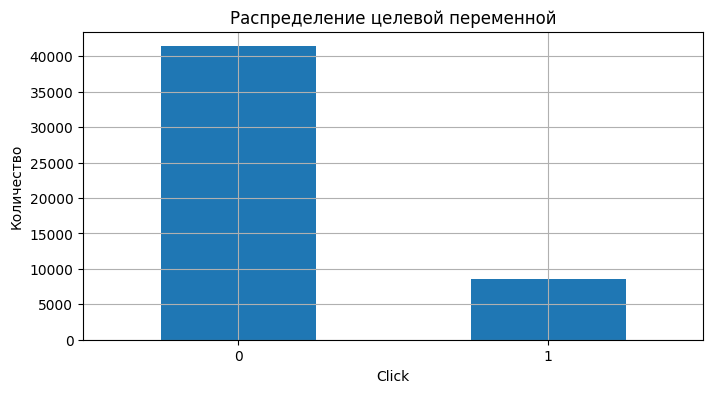

In [6]:
click_positive_count = df['click'].sum()
click_positive_ratio = click_positive_count / len(df)
print(f"Количество записей в положительном классе: {click_positive_count} ({click_positive_ratio * 100:.2f}%)")
print(f"Количество записей в нулевом классе: {len(df) - click_positive_count} ({(1 - click_positive_ratio) * 100:.2f}%)")
draw_barplot(df['click'].value_counts(),
             'Распределение целевой переменной',
             'Click',
             'Количество')

Наблюдается дисбаланс классов целевой переменной. Положительный класс (переход пользователя по ссылке) составляет 17.21% от всех показов рекламы

<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Мы обнаружили серьёзный дисбаланс при исследовании данных. Как дополнительные материалы, рекомендую статью <a href='https://dyakonov.org/2021/05/27/imbalance/'>Дисбаланс классов</a>, очень классная, как и весь блог Дьяконова.</font>

#### 2.3 Анализ категориальных признаков
- Для категориальных признаков с небольшим количеством значений (67 и менее) построим столбчатые диаграммы доли кликов.
- Для категориальных признаков с большим количеством значений построим столбчатые диаграммы сравнения полного количества с количеством кликов.
- В обоих случаях выведем 20 наибольших значений.
- Признак `hours` необходимо разбить на несколько признаков (год, месяц, день, час), чтобы было возможно выявить возможные циклические колебания.

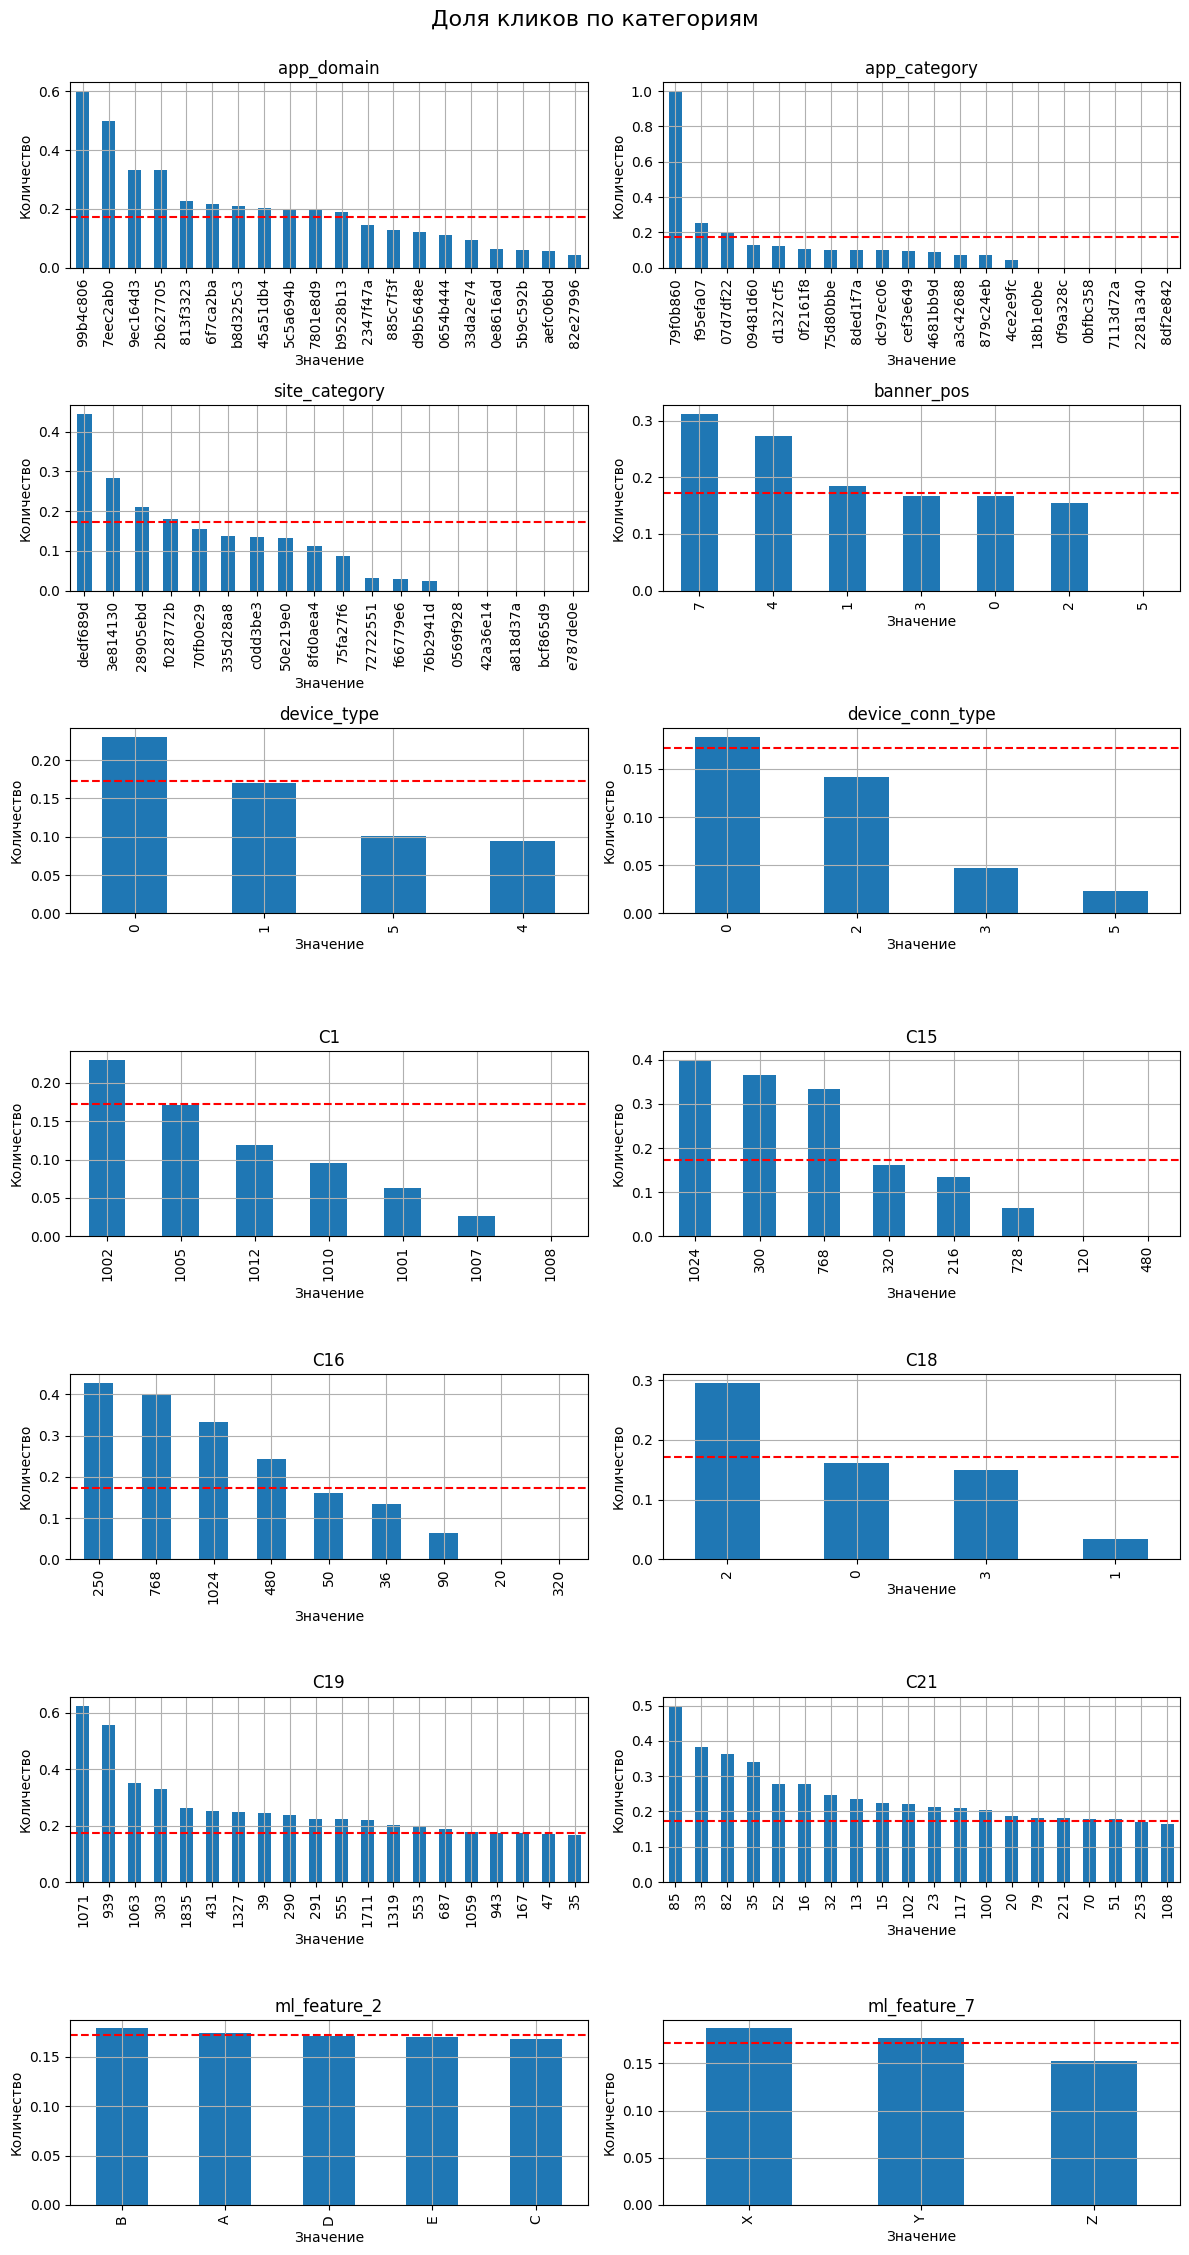

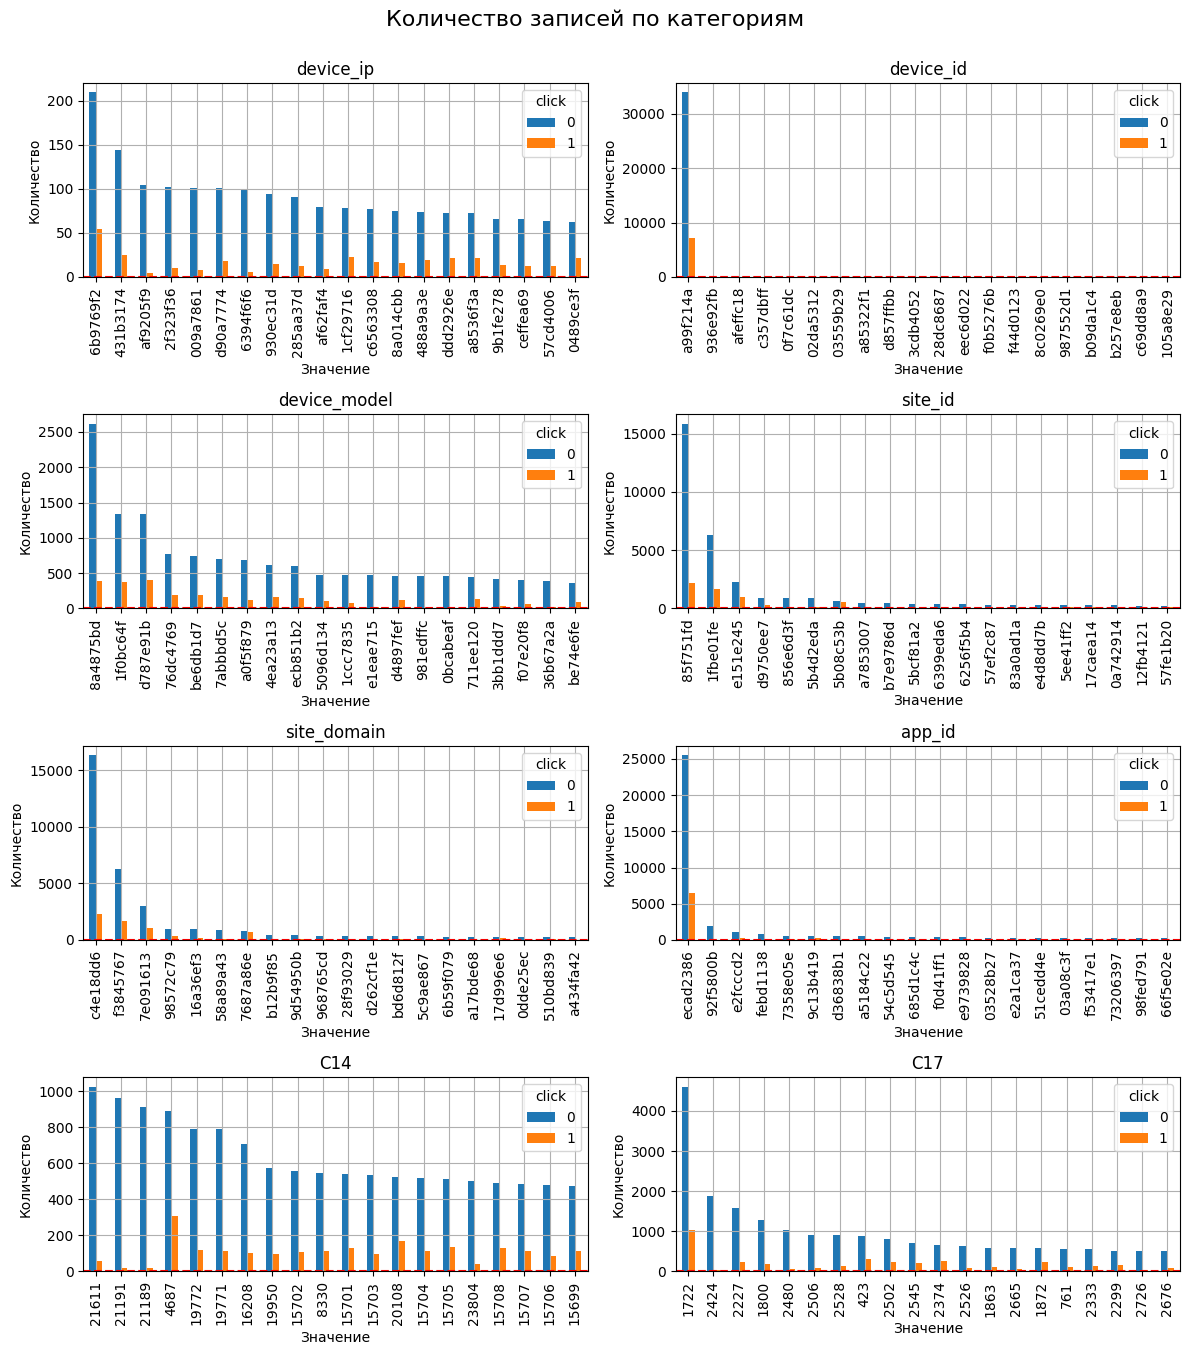

In [7]:
# Числовые признаки
num_features = ['ml_feature_1',
                'ml_feature_3',
                'ml_feature_5',
                'ml_feature_6',
                'ml_feature_8',
                'ml_feature_9',
                'ml_feature_10']

target=['click']
cat_features = list(set(df.columns) - set(['id'] + target + num_features))
cat_features_ratio = ['app_domain',
                      'app_category',
                      'site_category',
                      'banner_pos',
                      'device_type',
                      'device_conn_type',
                      'C1',
                      'C15',
                      'C16',
                      'C18',
                      'C19',
                      'C21',
                      'ml_feature_2',
                      'ml_feature_7',
                      'ml_feature_4']

cat_features_qty = ['device_ip', 
                    'device_id', 
                    'device_model',
                    'site_id',                    
                    'site_domain',
                    'app_id',
                    'C14', 
                    'C17',
                    'C20']

fig, axes = plt.subplots(len(cat_features_ratio) // 2, 2, figsize=(12, len(cat_features_ratio) * 1.5))

for i, ax in enumerate(axes.flatten()):
    draw_barplot_grid(
            # (df
            # .groupby(by=cat_features[i // 2])['click']
            # .value_counts()
            # .unstack(fill_value=0)
            # .sort_values(by=0, ascending=False)),
            (df
            .groupby(by=cat_features_ratio[i])['click']
            .mean()
            .sort_values(ascending=False)
            .head(20)),       
            cat_features_ratio[i], 
            "Значение", 
            "Количество", 
            90, 
            True, 
            click_positive_ratio,
            ax)

plt.suptitle("Доля кликов по категориям", fontsize=16, y=1)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(cat_features_qty) // 2, 2, figsize=(12, len(cat_features_qty) * 1.5))

for i, ax in enumerate(axes.flatten()):
    draw_barplot_grid(
            (df
            .groupby(by=cat_features_qty[i])['click']
            .value_counts()
            .unstack(fill_value=0)
            .sort_values(by=0, ascending=False)),
            cat_features_qty[i], 
            "Значение", 
            "Количество", 
            90, 
            True, 
            click_positive_ratio,
            ax)
plt.suptitle("Количество записей по категориям", fontsize=16, y=1)
plt.tight_layout()
plt.show()    

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<span style="color: darkorange"> По какому принципу разделены признаки на num_features и cat_features  </span>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента.</span><br>
<span style="color: darkorange">
Числовые признаки - с типом `float64` и количеством значений, равным объему выборки.
Категориальные - исходя из логики (IP-адрес, ID устройства) и такие, у которых количество значений намного меньше объема выборки. Где-то это очевидно (2-10 значений), для других (`C14`, `C17`) я построил диаграммы распределения, из которых стало ясно, что значения не упорядочены и не распределены так, как полагается числовым. Все эти промежуточные шаги я не стал здесь приводить, чтобы не загромождать проект.</span>


- У признака `device_id` основное количество записей сконцентрировано на одном значении, причем доля кликов на нем примерно соответствует доле кликов на всем датасете. Вероятно, это значение является заглушкой для пропусков. Этот признак неинформативен, его можно удалить из обучения.
- У признака `device_ip` очень большое количество уникальных значений. В большинстве сценариев этот признак будет случайным (IP-адрес мобильного устройства или точки доступа WiFi), а его повторение - маловероятным, поэтому его влияние на целевую переменную тоже имеет случайный характер. Его также следует удалить из обучения.
- У остальных признаков видно неравномерное распределение доли кликов по значениям, поэтому удалять их на этом этапе нецелесообразно.
- Признаки с количеством значений от 3 до 9 могут быть закодированы методом One-Hot Encoding, для прочих категориальных признаков целесообразно использовать метод Target Encoding.

#### 2.4. Анализ числовых признаков
- Исследуем распределения числовых признаков:

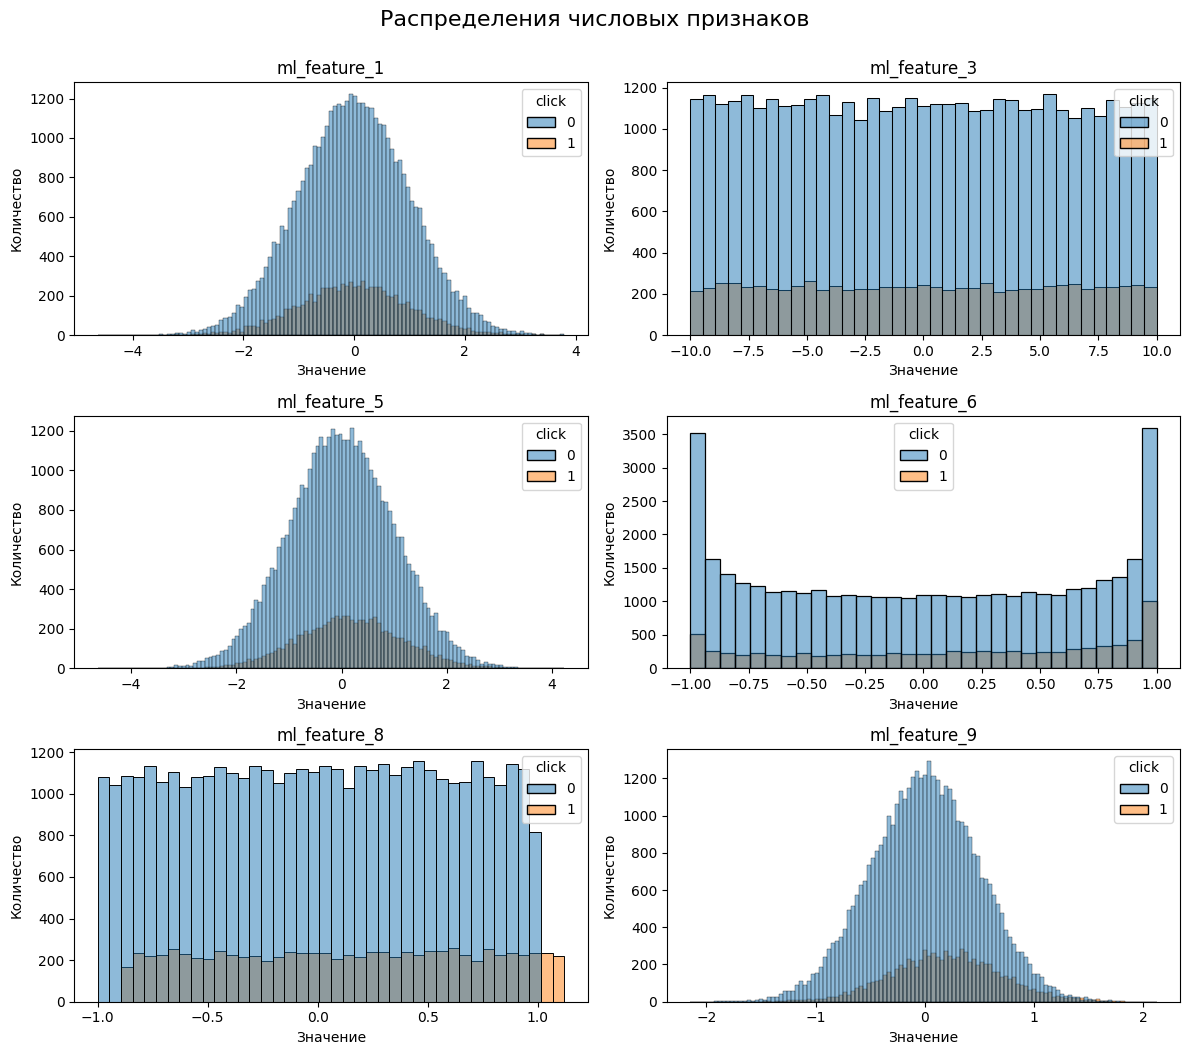

,ml_feature_1,ml_feature_3,ml_feature_5,ml_feature_6,ml_feature_8,ml_feature_9,ml_feature_10
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,-0.002445,-0.036381,0.034729,0.022948,0.025465,0.035361,0.020226
std,1.000280,5.792335,1.002116,0.656690,0.578026,0.505034,0.303309
min,-4.631262,-9.999742,-4.631853,-1.000000,-0.999965,-2.147526,-1.287965
25%,-0.677784,-5.059555,-0.639829,-0.579775,-0.470627,-0.304077,-0.182386
50%,-0.003776,-0.056155,0.028112,0.037786,0.027348,0.035985,0.018930
75%,0.673534,4.985939,0.707594,0.637131,0.521117,0.374152,0.224080
max,3.793828,9.999975,4.230623,1.000000,1.119858,2.120786,1.202300


In [8]:
fig, axes = plt.subplots(len(num_features) // 2, 2, figsize=(12, len(num_features) * 1.5))

for i, ax in enumerate(axes.flatten()):
    draw_histogram_grid(
            df,
            num_features[i],
            num_features[i], 
            "Значение", 
            "Количество", 
            **{'ax': ax,
               'hue': 'click'})
    
plt.suptitle("Распределения числовых признаков", fontsize=16, y=1)
plt.tight_layout()
plt.show()

display(df[num_features].describe())

- Распределения признаков `ml_feature_1`, `ml_feature_5`, `ml_feature_9` близки к нормальным. Классы целевой переменной распределены так же (у `ml_feature_9` распределение кликов немного сдвинуто вправо).
- Распределения признаков `ml_feature_3`, `ml_feature_8` близки к равномерным, как и распределения количества кликов по этим признакам. Признак `ml_feature_3` бесполезен для обучения и может быть удален.
- Значения `ml_feature_8`, соответствующие положительному классу, сдвинуты вправо относительно значений нулевого класса и выходят за пределы интервала $[-1, 1]$. Вероятно, для записей, относящихся к положительному классу, этот признак указан с ошибкой. Если это действительно так, данный признак тоже должен быть удален, потому что ошибочные значения приведут к неправильному обучению модели. Однако на предоставленном датасете распределения обучающей и тестовой выборок будут совпадать, поэтому в рамках данного проекта признак `ml_feature_8` будет оставлен в неизменном виде.

Разобьем признак `hours` на составляющие: месяц, день и час и построим диаграммы распределения этих признаков.

,raw_hour,month,day,hour,click
0,14102100,1410,21,0,1
1,14102100,1410,21,0,0
2,14102100,1410,21,0,0
3,14102100,1410,21,0,0
4,14102100,1410,21,0,0


Количество уникальных значений:


raw_hour    240
month         1
day          10
hour         24
click         2
dtype: int64

Распределение доли кликов по часам:


count    24.000000
mean      0.172816
std       0.012918
min       0.148988
25%       0.163071
50%       0.173535
75%       0.184231
max       0.193576
Name: click, dtype: float64

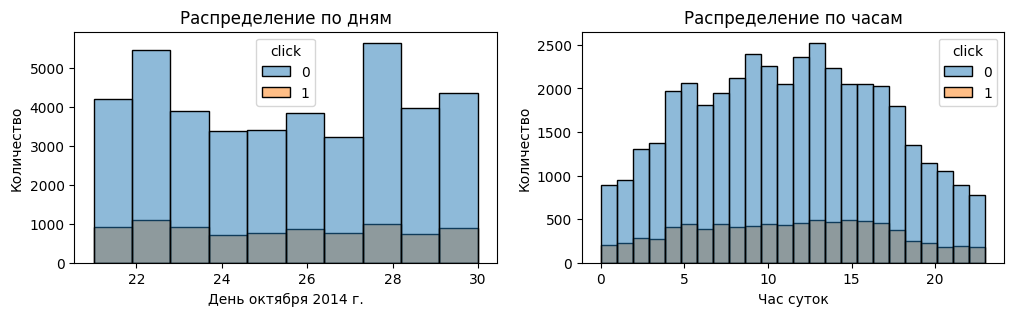

In [9]:
df_hours = pd.DataFrame({
    'raw_hour': df['hour'],
    'month': df['hour'] // 10000,
    'day': df['hour'] % 10000 // 100,
    'hour': df['hour'] % 100,
    'click': df['click']
})

display(df_hours.head())

print("Количество уникальных значений:")
display(df_hours.nunique())

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
draw_histogram_grid(
            df_hours,
            'day',
            "Распределение по дням", 
            "День октября 2014 г.", 
            "Количество", 
            ax = axes[0],
            hue = 'click',
            bins = df_hours['day'].nunique())

draw_histogram_grid(
            df_hours,
            'hour',
            "Распределение по часам", 
            "Час суток", 
            "Количество", 
            ax = axes[1],
            hue = 'click',
            bins = df_hours['hour'].nunique())

print("Распределение доли кликов по часам:")
display(df_hours.groupby(by='hour')['click'].mean().describe())

- Данные собраны за 10 дней октября 2014 года. Количество дней слишком мало, чтобы установить недельные или месячные колебания целевой переменной. Единственным признаком, который можно взять для машинного обучения является час суток. 
- На диаграмме видны суточные колебания количества обращений - основной объем приходится на часы с 4 по 18, однако доля кликов различается незначительно - ее стандартное отклонение по часам равно 0.01.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### 2.5. Анализ корреляций
Изучим корреляции признаков между собой и с целевой переменной. Среди признаков есть категориальные с большим количеством значений. Для лучшей эффективности анализа заменим их на Target Encoding (посчитаем среднее значение класса для каждой категории).

**NB:** Значения Target Encoding, получаемые на этом этапе, не будут использоваться при обучении модели, поэтому утечки данных не возникнет. Кодирование используется только для более эффективного вычисления корреляции между признаками.

interval columns not set, guessing: ['click', 'C1', 'banner_pos', 'site_id', 'site_domain', 'app_id', 'app_domain', 'device_model', 'device_type', 'device_conn_type', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21', 'ml_feature_1', 'ml_feature_4', 'ml_feature_5', 'ml_feature_6', 'ml_feature_8', 'ml_feature_9', 'ml_feature_10', 'hour']


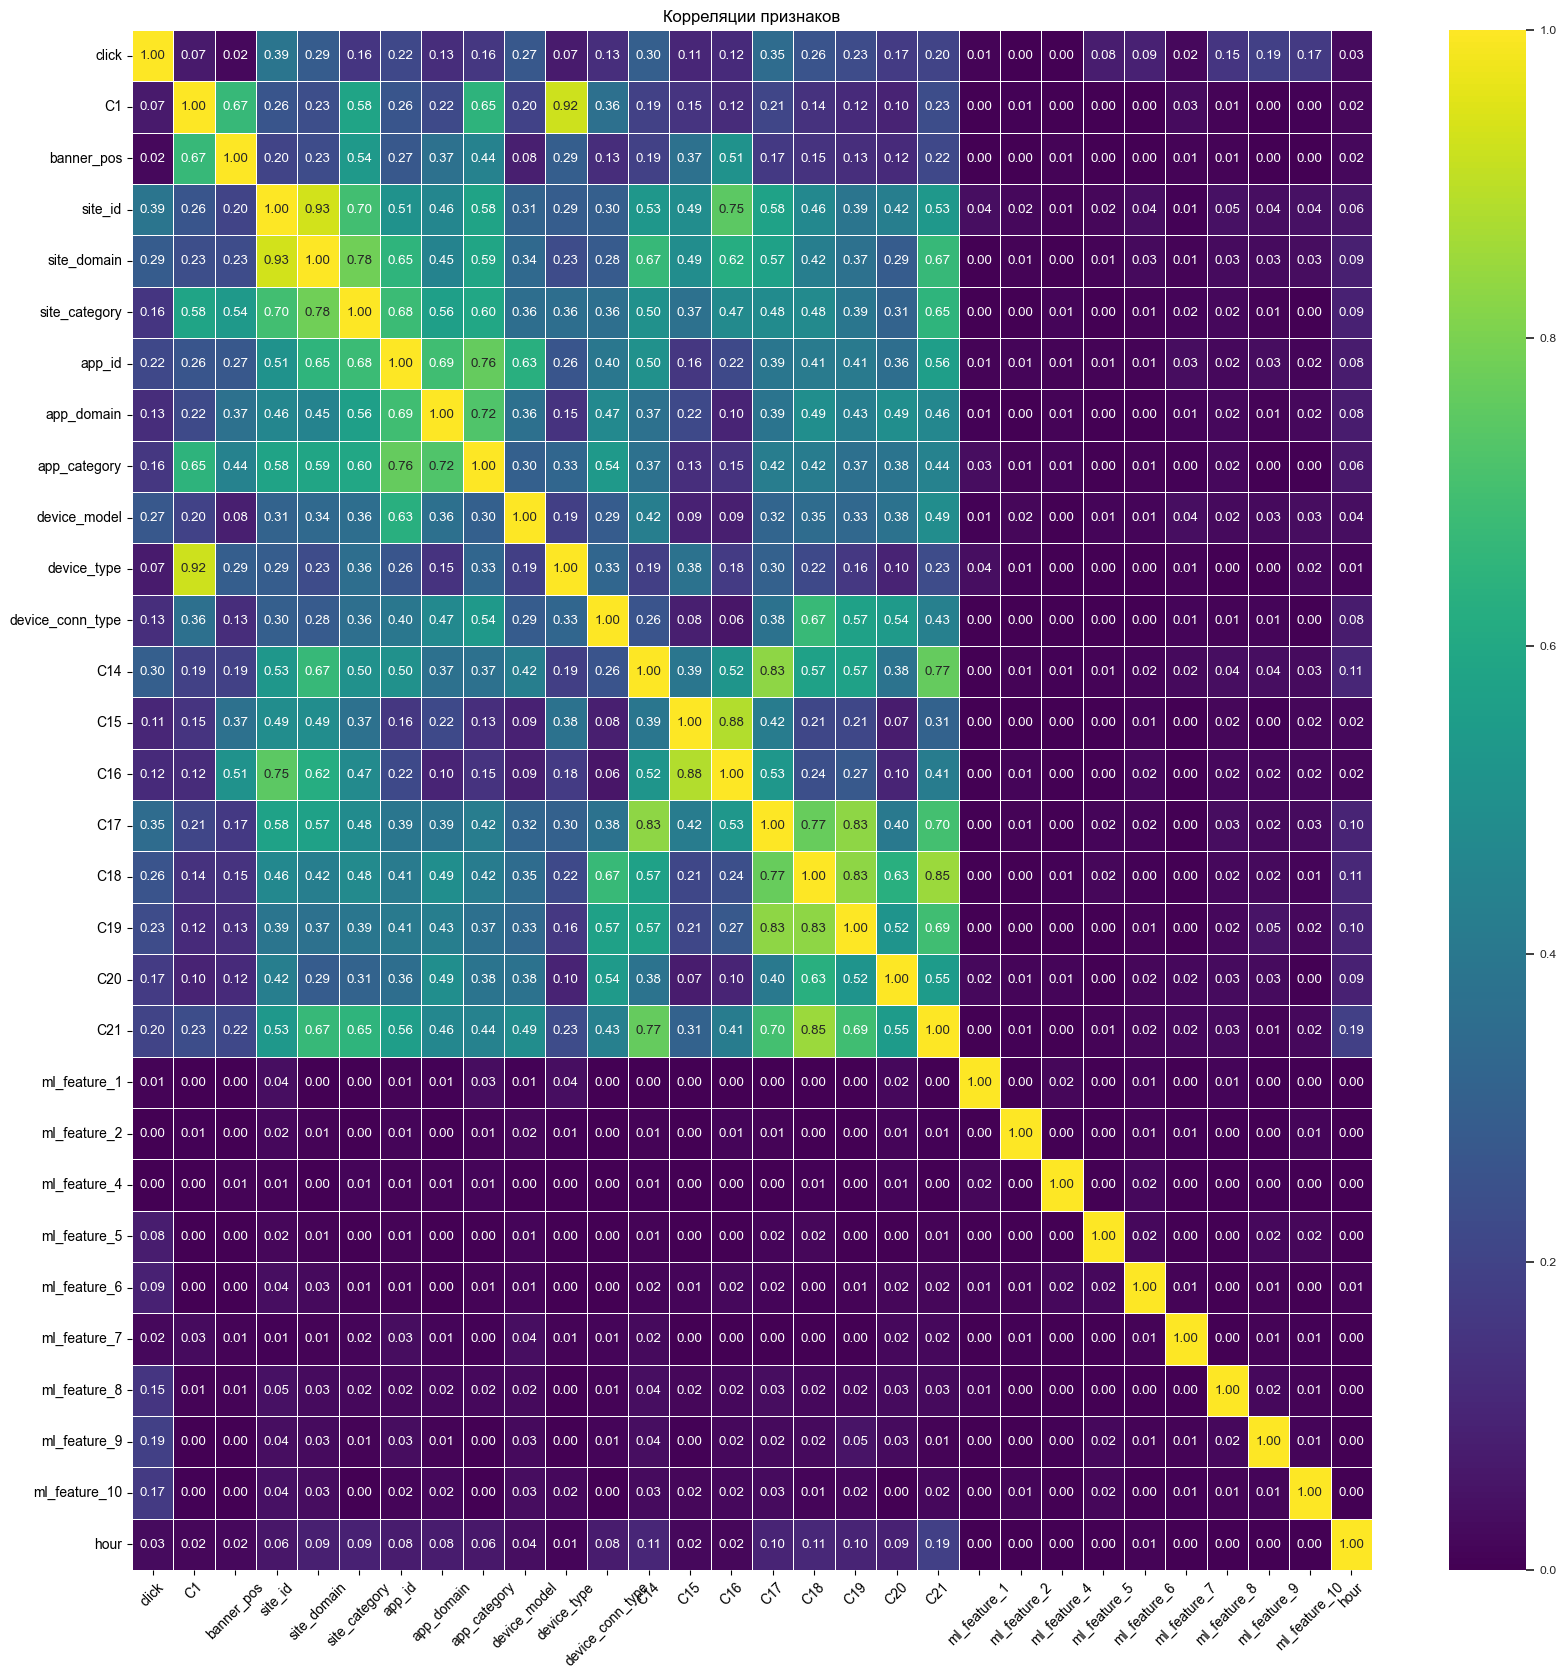

In [10]:
# Заменяем колонку hour на час суток
corr_df = pd.concat([df.drop(columns=['hour']),
                    df_hours['hour']], axis=1)

# Получаем признаки с количеством значений более 30
cat_card = df[cat_features].nunique() > 30
card_cols = cat_card[cat_card].index.to_list()

# Кодируем признаки с использованием Target Encoding
for col in card_cols:
    target_mean = corr_df.groupby(col)['click'].mean()
    corr_df[col] = corr_df[col].map(target_mean)
corr_df.drop(columns=['id', 'device_id', 'device_ip', 'ml_feature_3'], inplace=True)

# Вычисление корреляции при помощи φk
phik_matrix = phik.phik_matrix(corr_df)
draw_heatmap(phik_matrix, "Корреляции признаков", figsize=(20, 20))

- Корреляция целевой переменной со всеми признаками довольно слабая, максимальное значение, 0.39 - с признаком `site_id`. Следующие признаке по силе корреляции - `C17`, `C14`, `site_domain`.
- Сильно коррелируют между собой `C1` и `device_type`, а также `site_domain` и `site_id`. Из этих двух пар можно оставить по одному признаку.
- Присутствуют сильные корреляции внутри группы признаков `C14`-`C21`. Поскольку признаки анонимизированы, и их смысл неясен, предлагается их оставить до этапа отбора признаков.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Здорово,что применена `phik` для анализа и нелинейных зависимостей</font>

#### 2.6. Выводы:
1. Количество записей в исходном датасете - 50000. Пропуски и явные дубликаты отсутствуют.
2. Датасет содержит 33 признака и одну целевую переменную (`click`).
3. Классы целевой переменной несбалансированы. Положительный класс (переход пользователя по ссылке) составляет 17.21% от всех показов рекламы.
4. По результатам анализа распределения признаков было решено удалить дискретные признаки `id`, `device_id`, `device_ip`, непрерывный числовой признак `ml_feature_3`, распределенный равномерно относительно целевой переменной, а также признак `hour`.
5. По результатам анализа корреляций установлено, что наибольшая корреляция целевой переменной наблюдается с признаками `site_id`, `C17`, `C14`, `site_domain`, однако максимальное значение корреляции невелико - 0.39.
6. Пары признаков `C1` и `device_type`, а также `site_domain` и `site_id` сильно коррелируют между собой. Из этих двух пар можно оставить по одному признаку.
7. Категориальные признаки с количеством значений от 3 до 9 могут быть закодированы при помощи One-Hot Encoding, для признаков с большим количеством значений следует использовать метод Target Encoding.

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'>Хорошая работа в части исследования данных: молодец, что используешь функции, а также применяешь подходящие для типов данных инструменты.</font>

## 3. Разделение данных на выборки

#### 3.1 Разделение данных

- Разделим датасет на обучающую, калибрацинную и тестовую выборки:

In [11]:
# Числовые признаки
num_features = ['ml_feature_1',
#                'ml_feature_3',
                'ml_feature_5',
                'ml_feature_6',
                'ml_feature_8',
                'ml_feature_9',
                'ml_feature_10']

# Таргет
target = 'click'

# Категориальные признаки
cat_features = [#'C1',
                'C14',
                'C15',
                'C16',
                'C17',
                'C18',
                'C19',
                'C20',
                'C21',
                'app_category',
                'app_domain',
                'app_id',
                'banner_pos',
                'device_conn_type',
#                'device_id',
#                'device_ip',
                'device_model',
                'device_type',
                'hour',
                'ml_feature_2',
                'ml_feature_4',
                'ml_feature_7',
                'site_category',
#                'site_domain',
                'site_id']

all_features = num_features + cat_features

X = df[all_features]
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    shuffle=True, 
                                                    stratify=y, 
                                                    random_state=RANDOM_SEED)

X_train, X_calib, y_train, y_calib = train_test_split(X_temp, y_temp, 
                                                    test_size=0.25, 
                                                    shuffle=True, 
                                                    stratify=y_temp, 
                                                    random_state=RANDOM_SEED)

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Здорово, что есть независимая выборка для калибровки.</font>

<font color='blue'><b>Комментарий ревьюера: </b></font> ⚠️\
<font color='darkorange'> Закомментированный код лучше удалять из проекта. Он создаёт впечатление неоконченой работы.</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента.</span><br>
<span style="color: darkorange">
В данном случае комментарии показывают, какие признаки были удалены по результатам EDA. Они оставлены специально.</span>


#### 3.2. Проверка разделения

In [12]:

train_pos_ratio = y_train.sum() / len(y_train)
print(f"Положительный класс в исходном датасете: {y.sum().sum() / len(y) * 100:.2f}%")
print(f"Положительный класс в train: {y_train.sum().sum() / len(y_train) * 100:.2f}%")
print(f"Положительный класс в test: {y_test.sum().sum() / len(y_test) * 100:.2f}%")
print(f"Положительный класс в calib: {y_calib.sum().sum() / len(y_calib) * 100:.2f}%")
print(f"Размеры выборок: train: {len(y_train)}, test: {len(y_test)}, calib: {len(y_calib)}")

Положительный класс в исходном датасете: 17.21%
Положительный класс в train: 17.21%
Положительный класс в test: 17.21%
Положительный класс в calib: 17.20%
Размеры выборок: train: 30000, test: 10000, calib: 10000


Разделение проведено, доля положительного класса в обеих выборках совпадает с долей в исходном датасете.

## 4. Предобработка данных — построение пайплайнов

Опишем функцию для создания пайплайна с предобработкой и классификатором:
- Для числовых признаков проведем масштабирование (стандартизацию)
- Кодирование категориальных признаков с количеством значений менее 10 при помощи One-Hot Encoding, признаков с большим количеством значений - Target Encoding.

In [13]:
# Функция для извлечения часа из признака hour
def hour_extractor(X):
    X = X.copy()
    X['hour'] = X['hour'] % 100
    return X

# Функция для создания пайплайна предобработки
def create_pp_pipeline(feature_num_cols, ohe_cols, target_enc_cols, feature_engineering):
    # Собранный препроцессинг
    rv = Pipeline([
                    ('ct', ColumnTransformer([
                        ('hour_extract', FunctionTransformer(hour_extractor), ['hour']),
                        ('cat_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ohe_cols),
                        ('cat_target', TargetEncoder(random_state=RANDOM_SEED), target_enc_cols),
                        ('num', StandardScaler(), feature_num_cols)
                    ])),
                    ('feature_eng', FunctionTransformer(feature_engineering, validate=False))])

    rv.set_output(transform="pandas")
    return rv

# Функция для создания пайплайна предобработки и классификации
def create_pipeline(feature_num_cols, ohe_cols, target_enc_cols, feature_engineering, classifier):
    preprocess = create_pp_pipeline(feature_num_cols, ohe_cols, target_enc_cols, feature_engineering)

    return Pipeline([
        ('preprocess', preprocess),
        ('classify', classifier)
    ])

cat_card = X_train[cat_features].nunique()
cat_ohe_features = cat_card[(cat_card > 2) & (cat_card < 10)].index.to_list()
cat_te_features = cat_card[cat_card >= 10].index.to_list()
print("Признаки для кодирования OHE:")
display(cat_ohe_features)
print("Признаки для кодирования Target Enconding:")
display(cat_te_features)

Признаки для кодирования OHE:


['C15',
 'C16',
 'C18',
 'banner_pos',
 'device_conn_type',
 'device_type',
 'ml_feature_2',
 'ml_feature_7']

Признаки для кодирования Target Enconding:


['C14',
 'C17',
 'C19',
 'C20',
 'C21',
 'app_category',
 'app_domain',
 'app_id',
 'device_model',
 'hour',
 'site_category',
 'site_id']

Была написана функция создания пайплайна с предобработкой и моделью классификации, определены признаки для кодирования методами One-Hot Encoding, Target Encoding.

## 5. Отбор признаков

#### 5.1 Фильтрационные методы
- Выведем корреляцию целевой переменной с признаками: 

interval columns not set, guessing: ['hour_extract__hour', 'cat_ohe__C15_120', 'cat_ohe__C15_216', 'cat_ohe__C15_300', 'cat_ohe__C15_320', 'cat_ohe__C15_480', 'cat_ohe__C15_728', 'cat_ohe__C15_768', 'cat_ohe__C15_1024', 'cat_ohe__C16_20', 'cat_ohe__C16_36', 'cat_ohe__C16_50', 'cat_ohe__C16_90', 'cat_ohe__C16_250', 'cat_ohe__C16_320', 'cat_ohe__C16_480', 'cat_ohe__C16_768', 'cat_ohe__C16_1024', 'cat_ohe__C18_0', 'cat_ohe__C18_1', 'cat_ohe__C18_2', 'cat_ohe__C18_3', 'cat_ohe__banner_pos_0', 'cat_ohe__banner_pos_1', 'cat_ohe__banner_pos_2', 'cat_ohe__banner_pos_3', 'cat_ohe__banner_pos_4', 'cat_ohe__banner_pos_5', 'cat_ohe__banner_pos_7', 'cat_ohe__device_conn_type_0', 'cat_ohe__device_conn_type_2', 'cat_ohe__device_conn_type_3', 'cat_ohe__device_conn_type_5', 'cat_ohe__device_type_0', 'cat_ohe__device_type_1', 'cat_ohe__device_type_4', 'cat_ohe__device_type_5', 'cat_ohe__ml_feature_2_A', 'cat_ohe__ml_feature_2_B', 'cat_ohe__ml_feature_2_C', 'cat_ohe__ml_feature_2_D', 'cat_ohe__ml_feature

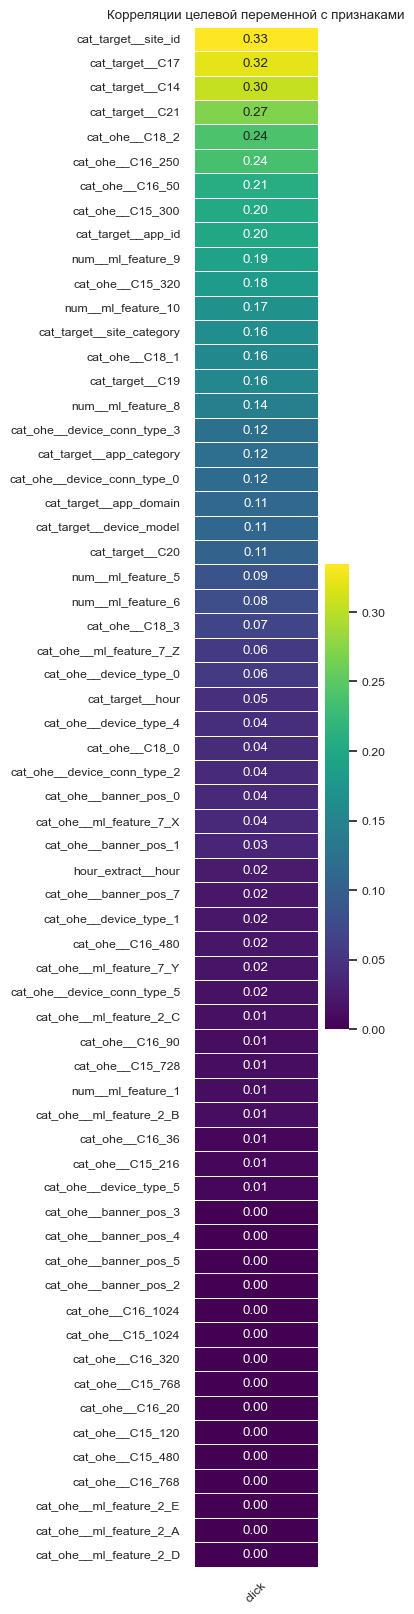

In [14]:
pp = create_pp_pipeline(num_features, cat_ohe_features, cat_te_features, lambda X: X)
X_train_pp = pp.fit_transform(X_train, y_train)
X_train_pp.index = y_train.index
# corr_matrix = (np.abs(pd.concat([X_train_corr, y_train], axis=1)
#                .corr(method='spearman')[[target]])
#                .sort_values(by=target, ascending=False))

corr_matrix = (phik.phik_matrix(pd.concat([X_train_pp, y_train], axis=1))[[target]]
               .sort_values(by=target, ascending=False)
               .drop(target))
#corr_matrix = pd.concat([X_train_corr, y_train], axis=1).corr()
draw_heatmap(corr_matrix, "Корреляции целевой переменной с признаками", figsize=(2, 20))

- Возьмем 7 признаков с наибольшим значением корреляции:

In [15]:
corr_threshold = 0.24
n_features_to_select = 7 #(round(corr_matrix[target], 2) >= corr_threshold).sum()
features_to_keep_corr = set(corr_matrix[:n_features_to_select].index.to_list())

print(f"Отобранные признаки:")
display(features_to_keep_corr)

# Примем за максимальное полученное на этом шаге количество признаков
n_features_to_select = len(features_to_keep_corr)

Отобранные признаки:


{'cat_ohe__C16_250',
 'cat_ohe__C16_50',
 'cat_ohe__C18_2',
 'cat_target__C14',
 'cat_target__C17',
 'cat_target__C21',
 'cat_target__site_id'}

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

- Получим список числовых признаков с низкой дисперсией:

In [16]:
vs_constant = VarianceThreshold(threshold=0.01) 
vs_constant.fit(X_train[num_features])
features_to_delete_const = {X for X, keep in zip(X_train_pp.columns,
                                                 vs_constant.get_support()) if not keep}
print("Константные признаки (дисперсия < 0.01):")
display(features_to_delete_const)

Константные признаки (дисперсия < 0.01):


set()

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

Константных числовых  признаков нет.

- Получим признаки с максимальной метрикой взаимной информации с целевой переменной:

In [17]:
mi_scores = mutual_info_classif(X_train_pp, y_train, random_state=RANDOM_SEED)
top_idx = sorted(range(len(X_train_pp.columns)), 
                 key = lambda i: mi_scores[i], reverse=True)[:n_features_to_select]
features_to_keep_mi = {X_train_pp.columns[i] for i in top_idx}

print("Признаки с максимальной Mutual Information:")
display(features_to_keep_mi)

Признаки с максимальной Mutual Information:


{'cat_target__C14',
 'cat_target__C17',
 'cat_target__C19',
 'cat_target__C21',
 'cat_target__app_id',
 'cat_target__site_id',
 'num__ml_feature_8'}

#### 5.2 Отбор при помощи методов-обёрток

- Запустим отбор признаков при помощи методов-обёрток:

In [18]:
lr_estimator = LogisticRegression(random_state=RANDOM_SEED, solver='liblinear')

rfe_selector = RFE(lr_estimator, step=1, n_features_to_select=n_features_to_select)

rfe_selector.fit(X_train_pp, y_train)
features_to_keep_lr_rfe = {X for X, keep in zip(X_train_pp.columns, 
                                                  rfe_selector.get_support()) if keep}

print("Наиболее важные признаки согласно RFE:")
display(features_to_keep_lr_rfe)

# 10 наиболее важных признаков по SFS
lr_estimator2 = LogisticRegression(random_state=RANDOM_SEED, solver='liblinear')
sfs_selector = SFS(lr_estimator2, k_features=n_features_to_select, cv=5, 
                   scoring='f1', n_jobs=-1)
sfs_selector.fit(X_train_pp, y_train)
features_to_keep_lr_sfs = set(sfs_selector.k_feature_names_)

print("Наиболее важные признаки согласно SFS:")
display(features_to_keep_lr_sfs)

Наиболее важные признаки согласно RFE:


{'cat_target__C17',
 'cat_target__C19',
 'cat_target__C20',
 'cat_target__app_id',
 'cat_target__hour',
 'cat_target__site_category',
 'cat_target__site_id'}

Наиболее важные признаки согласно SFS:


{'cat_target__C17',
 'cat_target__C19',
 'cat_target__site_id',
 'num__ml_feature_10',
 'num__ml_feature_6',
 'num__ml_feature_8',
 'num__ml_feature_9'}

#### 5.3 Создание финального набора признаков
- Для дальнейшего обучения объединим существенные признаки, выявленные на предыдущих этапах:

In [19]:
selected_features = (features_to_keep_mi |
                    features_to_keep_corr |
                    features_to_keep_lr_rfe |
                    features_to_keep_lr_sfs) - features_to_delete_const

print(f"Осталось {len(selected_features)} признаков из {len(X_train_pp.columns)}: ")
display(selected_features)

Осталось 16 признаков из 63: 


{'cat_ohe__C16_250',
 'cat_ohe__C16_50',
 'cat_ohe__C18_2',
 'cat_target__C14',
 'cat_target__C17',
 'cat_target__C19',
 'cat_target__C20',
 'cat_target__C21',
 'cat_target__app_id',
 'cat_target__hour',
 'cat_target__site_category',
 'cat_target__site_id',
 'num__ml_feature_10',
 'num__ml_feature_6',
 'num__ml_feature_8',
 'num__ml_feature_9'}

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### Выводы:
- Отбор признаков для обучения был произведен с использованием следующих методов:
    1. Изучение корреляций признаков с целевой переменной.
    2. Изучение дисперсии числовых признаков.
    3. Изучение метрики Mutual Information с целевой переменной.
    4. Использование метода прямого отбора признаков с моделью логистической регресии и кросс-валидацией.
    5. Использование метода рекурсивного исключения признаков с моделью логистической регресии и кросс-валидацией.
- Наборы лучших признаков по всем методам были объединены, для обучения были оставлены 16 признаков из 63.

## 6. Обучение базовой модели

### 6.1 Обучение `DummyClassifier`

- Обучим базовую модель на основе `DummyClassifier`:

In [20]:
# Функция, удаляющая лишние признаки
def optimize_features(X):
    X_new = X[list(selected_features)].copy()
    return X_new

# Функция для расчета метрик
def calc_metrics(y, y_pred_proba, threshold=0.5, prefix='train_'):
    y_pred = (y_pred_proba >= threshold)
    return {(prefix + 'accuracy'): accuracy_score(y, y_pred),
            (prefix + 'f1'): f1_score(y, y_pred),
            (prefix + 'average_precision'): average_precision_score(y, y_pred_proba),
            (prefix + 'precision'): precision_score(y, y_pred, zero_division=0),
            (prefix + 'recall'): recall_score(y, y_pred),
            (prefix + 'neg_log_loss'): -log_loss(y, y_pred_proba),
            (prefix + 'brier_loss'): brier_score_loss(y, y_pred_proba)}    

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# dummy_pipeline.fit(X_train, y_train)
dummy_metrics_tmp = cross_validate(DummyClassifier(random_state=RANDOM_SEED),
                               X_train,
                               y_train,
                               scoring=['accuracy',
                                    'f1',
                                    'average_precision',
                                    'precision',
                                    'recall',
                                    'neg_log_loss'],
                                cv=cv,
                                return_train_score = True,
                                return_estimator = True,
                                n_jobs=-1)
dummy_metrics = pd.DataFrame(dummy_metrics_tmp).iloc[:, 3:].mean()
# y_train_proba_dummy = dummy_pipeline.predict_proba(X_train)[:, 1]
# dummy_metrics = calc_metrics(y_train, y_train_proba_dummy)
display(pd.DataFrame({
    'DummyClassifier': dummy_metrics}))

,DummyClassifier
test_accuracy,0.827933
train_accuracy,0.827933
test_f1,0.000000
train_f1,0.000000
test_average_precision,0.172067
train_average_precision,0.172067
test_precision,0.000000
train_precision,0.000000
test_recall,0.000000
train_recall,0.000000


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Классно, что сравниваешь с константной моделью!</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'> Для DummyClassifier не нужен препроцессор. Он полностью игнорирует X.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ❌\
<font color='red'> Для DummyClassifier тоже нужна кросс-валидация, чтобы её результат можно было сравнивать с результатами кросс-валидаций остальных моделей</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента.</span><br>
<span style="color: darkorange">
Исправил, но есть вопрос: зачем проводить кросс-валидацию `DummyRegressor`, если и на всей выборке, и на стратифицированных фолдах он все равно выдает одинаковые значения? Он ведь зависит только от доли положительного класса в обучающей выборке, которая при стратификации останется такой же и на фолдах.</span>

### 6.2 Обучение модели логистической регрессии

In [21]:
lr_pipeline = create_pipeline(num_features,
                            cat_ohe_features,
                            cat_te_features,
                            optimize_features,
                            LogisticRegression(random_state=RANDOM_SEED))

lr_metrics = cross_validate(lr_pipeline, 
                            X_train, 
                            y_train, 
                            scoring=['accuracy',
                                        'f1',
                                        'average_precision',
                                        'precision',
                                        'recall',
                                        'neg_log_loss'],
                            cv=cv,
                            return_train_score = True,
                            return_estimator = True,
                            n_jobs=-1)

display(pd.DataFrame({
    'DummyClassifier': dummy_metrics,
    'LogisticRegression': pd.DataFrame(lr_metrics).iloc[:, 3:].mean()}))

,DummyClassifier,LogisticRegression
test_accuracy,0.827933,0.836100
train_accuracy,0.827933,0.846750
test_f1,0.000000,0.217345
train_f1,0.000000,0.284317
test_average_precision,0.172067,0.406005
train_average_precision,0.172067,0.499154
test_precision,0.000000,0.609219
train_precision,0.000000,0.723709
test_recall,0.000000,0.132314
train_recall,0.000000,0.176918


### 6.3 Обучение модели SVM

- Обучим модель SVM и сравним ее с базовой и логистической регрессией:

In [22]:
svc_pipeline = create_pipeline(num_features,
                            cat_ohe_features,
                            cat_te_features,
                            optimize_features,
                            SVC(kernel='linear', 
                                probability=False,
                                random_state=RANDOM_SEED))

svc_metrics = cross_validate(svc_pipeline, 
                            X_train, 
                            y_train, 
                            scoring=['accuracy',
                                        'f1',
                                        'average_precision',
                                        'precision',
                                        'recall'],
                            cv=cv,
                            return_train_score = True,
                            return_estimator = True,
                            n_jobs=-1)

display(pd.DataFrame({
    'DummyClassifier': dummy_metrics,
    'LogisticRegression': pd.DataFrame(lr_metrics).iloc[:, 3:].mean(),
    'SVM': pd.DataFrame(svc_metrics).iloc[:, 3:].mean()}))

,DummyClassifier,LogisticRegression,SVM
test_accuracy,0.827933,0.836100,0.827933
test_average_precision,0.172067,0.406005,0.330718
test_f1,0.000000,0.217345,0.000000
test_neg_log_loss,-0.459148,-0.397109,NaN
test_precision,0.000000,0.609219,0.000000
test_recall,0.000000,0.132314,0.000000
train_accuracy,0.827933,0.846750,0.827933
train_average_precision,0.172067,0.499154,0.453815
train_f1,0.000000,0.284317,0.000000
train_neg_log_loss,-0.459148,-0.369924,NaN


#### 6.4. Выводы
- Модель логистической регрессии с гиперпараметрами по умолчанию показывает лучшие результаты по всем метрикам, чем базовая `DummyClassifier`. Основная метрика PR-AUC у логистической регрессии больше почти в 3 раза.
- Неоткалиброванная модель SVM с линейным ядром и гиперпараметрами по умолчанию показывает результат по метрике PR-AUC лучше, чем базовая (0.45 против 0.17), но хуже, чем логистическая регрессия (0.45 против 0.5). По метрике `accuracy` SVM находится на уровне базовой модели. Можно попробовать улучшить результаты подбором гиперпараметров.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 7. Подбор гиперпараметров: Grid Search с кросс-валидацией
#### 7.1 Определение сеток гиперпараметров
- Определим сетку гиперпараметров для логистической регрессии:
    1. `l1_ratio` - регуляризация L1 (`l1_ratio` = 1), L2 (`l1_ratio` = 0) или `elasticnet` (комбинация L1 и L2, поддерживается солвером `saga`).
    2. `C` - сила регуляризации (меньшие значения соответствуют более сильной регуляризации).

In [23]:
lr_param_grid = [
    {
        "classify__solver": ['liblinear'],
        "classify__l1_ratio": [0, 1],
        "classify__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "classify__solver": ['saga'],
        "classify__penalty": ["elasticnet"],
        "classify__l1_ratio": [0, 0.5, 1],
        "classify__C": [0.1, 1, 10]
    }
]

- Сетка параметров для SVM:
    1. `kernel` - тип ядра.
    2. `C` - сила регуляризации (меньшие значения соответствуют более сильной регуляризации).
    3. Для ядер `rbf`, `poly`, `sigmoid` параметр `gamma` - "радиус влияния" точек обучающей выборки на разделяющую гиперповерхность.
    4. Для ядра `poly` параметр `degree` - степень полинома, параметр `coef0` - свободный член.

In [24]:
svc_param_grid = [
    {
        "classify__kernel": ['linear'],
        "classify__C": [0.1, 1, 10]
    }
    # {
    #     "kernel": ['rbf'],
    #     "gamma": ['auto', 'scale'],
    #     "C": [0.1, 1, 10]
    # }
    # {
    #     "kernel": ['poly'],
    #     "svc_gamma": ['auto', 'scale'],
    #     "C": [0.1, 1, 10],
    #     "degree": [2, 3],
    #     "coef0": [0, 0.5, 1]
    # }
]

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Нужен SVC с линейным ядром </font>
> - Обучите SVC линейным ядром.

</span><br><span style="color: purple; font-weight: bold">Комментарий студента.</span><br>
<span style="color: darkorange">
Исправил, мне показалось, что замечание про линейное ядро относится к базовой модели SVC, а при подборе гиперпараметров нужно выбирать и тип ядра.</span>

#### 7.2. Применение `GridSearch`
- Выполним поиск по сетке гиперпараметров логистической регрессии:

In [25]:
# Получаем обучающую выборку с сокращенным набором признаков
# X_train_pp_opt = optimize_features(X_train_pp)

lr_grid_estimator = create_pipeline(num_features,
                                    cat_ohe_features,
                                    cat_te_features,
                                    optimize_features,
                                    LogisticRegression(random_state=RANDOM_SEED))

# Поиск по сетке параметров
lr_grid = GridSearchCV(estimator=lr_grid_estimator, #LogisticRegression(random_state=RANDOM_SEED), 
                        param_grid=lr_param_grid, 
                        cv=cv, 
                        scoring='average_precision', 
                        n_jobs=-1, 
                        verbose=1) 
lr_grid.fit(X_train, y_train)


# Обработка результатов
def top_10_results(lr_grid):
    lr_grid_results = pd.DataFrame(lr_grid.cv_results_)
    lr_grid_results = lr_grid_results.sort_values(by=["rank_test_score"])
    lr_grid_results = lr_grid_results.set_index(
    lr_grid_results["params"].apply(lambda x: "_".join(str(val) for val in x.values()))
        ).rename_axis("kernel")
    return lr_grid_results[["params", "rank_test_score", "mean_test_score", "std_test_score"]][:10]

# Лучшие параметры
lr_best_params = lr_grid.best_params_

Fitting 5 folds for each of 19 candidates, totalling 95 fits


c:\Users\TEXNH MAKPH\Projects\Yandex DS\ds-yandex\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


<font color='blue'><b>Комментарий ревьюера: </b></font> ✔️\
<font color='green'> Отлично, что есть табличка результатов для сравнения.</font>

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span>  ❌\
<font color='red'>Для корректной кросс-валидации, Всю предобработку (Кодирование, Масштабирование, Выбор признаков и т.д.) нужно объединить с обучением моделей классификации через Pipeline, для избегания утечек между обучающими и валидационными подвыборками.</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента.</span><br>
<span style="color: darkorange">Да, точно. Сделал.</span>

- Поиск по сетке параметров SVM:

In [26]:
svc_grid_estimator = create_pipeline(num_features,
                                    cat_ohe_features,
                                    cat_te_features,
                                    optimize_features,
                                    SVC(probability=False,
                                        random_state=RANDOM_SEED))

svc_grid = GridSearchCV(estimator=svc_grid_estimator, #SVC(random_state=RANDOM_SEED), 
                    param_grid=svc_param_grid, 
                    cv=cv, 
                    scoring='average_precision', 
                    n_jobs=-1, 
                    verbose=4) 
svc_grid.fit(X_train, y_train)

# Лучшие параметры
svc_best_params = svc_grid.best_params_

Fitting 5 folds for each of 3 candidates, totalling 15 fits


- Выведем наборы параметров и моделей, отсортированные по средней метрике PR_AUC:

In [27]:
pd.concat([top_10_results(lr_grid), top_10_results(svc_grid)]).sort_values(by='mean_test_score', 
                                                                           ascending=False)

,params,rank_test_score,mean_test_score,std_test_score
kernel,,,,
0.1_0.5_elasticnet_saga,"{'classify__C': 0.1, 'classify__l1_ratio': 0.5...",1,0.406908,0.008085
0.1_0_elasticnet_saga,"{'classify__C': 0.1, 'classify__l1_ratio': 0, ...",2,0.406785,0.007868
0.1_1_liblinear,"{'classify__C': 0.1, 'classify__l1_ratio': 1, ...",3,0.406333,0.008296
0.1_1_elasticnet_saga,"{'classify__C': 0.1, 'classify__l1_ratio': 1, ...",4,0.406262,0.008247
1_0_elasticnet_saga,"{'classify__C': 1, 'classify__l1_ratio': 0, 'c...",5,0.406101,0.007437
1_0_liblinear,"{'classify__C': 1, 'classify__l1_ratio': 0, 'c...",6,0.406039,0.007400
1_0.5_elasticnet_saga,"{'classify__C': 1, 'classify__l1_ratio': 0.5, ...",7,0.405987,0.007421
1_1_liblinear,"{'classify__C': 1, 'classify__l1_ratio': 1, 'c...",8,0.405907,0.007375
1_1_elasticnet_saga,"{'classify__C': 1, 'classify__l1_ratio': 1, 'c...",9,0.405844,0.007426


<font color='blue'><b>Комментарий ревьюера : </b></font> ⚠️\
<font color='darkorange'> Нужно сконкатенировать таблицы и отсортировать по метрике.</font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента.</span><br>
<span style="color: darkorange">Сделал.</span>

#### 7.3. Вывод
- Был выполнен подбор гиперпараметров моделей логистической регрессии и SVM для оптимизации метрики PR-AUC.
- Модель SVM с лучшим набором гиперпараметров показала худший результат, чем логистическая регрессия с первыми 10 наборами гиперпараметров.
- В качестве финальной выбирается модель логистической регрессии с параметрами `C` = 0.1, `l1_ratio` = 0.5.

## 8. Финальная модель

#### 8.1 Обучение финальной модели
- Обучим модель логистической регрессии с лучшим набором параметров:

In [28]:
# final_pipeline = create_pipeline(num_features,
#                                  cat_ohe_features,
#                                  cat_te_features,
#                                  optimize_features,
#                                  LogisticRegression(**lr_best_params))
# final_pipeline.fit(X_train, y_train)
final_pipeline = lr_grid.best_estimator_
y_proba_test = final_pipeline.predict_proba(X_test)[:, 1]

<span style="color: blue;: bold">Комментарий ревьюера : </span> ⚠️\
<font color='darkorange'>GridSearchCV возвращает оптимальную модель уже обученную на всех обучающих данных. `lr_grid.best_estimator_`, например. </font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента.</span><br>
<span style="color: darkorange">Исправил.</span>

- Таже обучим модель SVM с лучшим набором параметров:

In [29]:
# final_svm_pipeline = create_pipeline(num_features,
#                                  cat_ohe_features,
#                                  cat_te_features,
#                                  optimize_features,
#                                  SVC(**svc_best_params))
# final_svm_pipeline.fit(X_train, y_train)

final_svm_pipeline = svc_grid.best_estimator_
y_pred_test_svm = final_svm_pipeline.predict(X_test)

# Сырые оценки SVC
y_scores_test_svm = final_svm_pipeline.decision_function(X_test)

dec = final_svm_pipeline.decision_function(X_test)

#### 8.2 Подсчет метрик на тестовой выборке
- Посчитаем метрики логистической регрессии на тестовой выборке:

In [30]:
final_train_metrics = calc_metrics(y_train, final_pipeline.predict_proba(X_train)[:, 1], 
                                   prefix='test_')
final_test_metrics = calc_metrics(y_test, y_proba_test, prefix='test_')
display(pd.DataFrame({
    "Train": final_train_metrics,
    "Test": final_test_metrics}))

,Train,Test
test_accuracy,0.844600,0.832400
test_f1,0.264205,0.185617
test_average_precision,0.484065,0.391501
test_precision,0.712947,0.566766
test_recall,0.162146,0.110982
test_neg_log_loss,-0.375465,-0.402563
test_brier_loss,0.116159,0.125299


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

- Метрики SVM на тестовой выборке:

In [31]:
final_svm_train_metrics = calc_metrics(y_train, final_svm_pipeline.predict(X_train), 
                                   prefix='test_')
final_svm_test_metrics = calc_metrics(y_test, y_pred_test_svm, prefix='test_')
display(pd.DataFrame({
    "Train": final_svm_train_metrics,
    "Test": final_svm_test_metrics}))

print("Количество опорных векторов: ", len(final_svm_pipeline.named_steps['classify'].support_))

,Train,Test
test_accuracy,0.827933,0.827900
test_f1,0.000000,0.000000
test_average_precision,0.172067,0.172100
test_precision,0.000000,0.000000
test_recall,0.000000,0.000000
test_neg_log_loss,-6.201911,-6.203113
test_brier_loss,0.172067,0.172100


Количество опорных векторов:  10671


<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

- Метрика `PR-AUC`, а также остальные метрики ухудшаются на тестовой выборке. Модель показывает небольшое переобучение.
- Баланс сдвинут в сторону точности (`precision`) в ущерб полноте (`recall`). Это соотношение можно регулировать порогом вероятности, однако на данном этапе это нецелесообразно, так как для заказчика важна калибровка модели и ее способность предсказывать вероятности.
- Модель SVM с линейным ядром показывает результаты на уровне `DummyRegressor` и непригодна для практического применения. Вероятно, это происходит из-за чрезмерного переобучения на полном наборе данных.

#### 8.3 Анализ весов модели
- Определим самые важные признаки на основании абсолютных значений коэффициентов:

In [32]:
X_train_pp_opt = final_pipeline.named_steps['preprocess'].transform(X_train)

df_coef = pd.DataFrame({
    'coef': np.abs(final_pipeline.named_steps['classify'].coef_[0]),
    'Признак': X_train_pp_opt.columns.to_list()
}).sort_values(by='coef', ascending=False).reset_index(drop=True)

display(df_coef.style.background_gradient(cmap='viridis'))


,coef,Признак
0,2.663855,cat_target__site_id
1,2.493454,cat_target__app_id
2,1.704243,cat_target__C17
3,0.968766,cat_target__C14
4,0.750087,cat_target__C20
5,0.690436,cat_target__C21
6,0.620283,cat_target__C19
7,0.403285,num__ml_feature_9
8,0.350534,num__ml_feature_10
9,0.275967,cat_target__hour


Три наиболее важных признака совпадают с имеющими наибольшие коэффициенты корреляции с тестовой переменной.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### Выводы:
- Для моделей логистической регрессии и SVM были подобраны гиперпараметры, на которых метрика PR-AUC достигает максимума.
- Модель логистической регрессии показала лучшие результаты на всех 10 лучших наборах, чем модель SVM с лучшими параметрами.
- Обе модели показывают худшие результаты на тестовой выборке и демонстрируют переобучение. Модель SVM из-за переобучения получает метрики на уровне `DummyClassifier` и становится неприменимой, а дополнительным следствием переобучения становится большая вычислительная нагрузка при предсказаниях из-за большого количества опорных векторов.
- Три наиболее важных признака совпадают с имеющими наибольшие коэффициенты корреляции с целевой переменной. Два из них - идентификаторы приложения и сайта. Эти параметры в наибольшей степени определяют вероятность клика.

## 9. Калибровка модели

#### 9.1 Проверка текущей калибровки

- Построим калибровочную кривую для логистической регрессии и SVM.
- Поскольку к SVM с параметром `probability`=`True` по умолчанию применяется калибровка Платта, будем использовать модель без этого параметра, а сырые оценки получать при помощи метода `decision_function()`

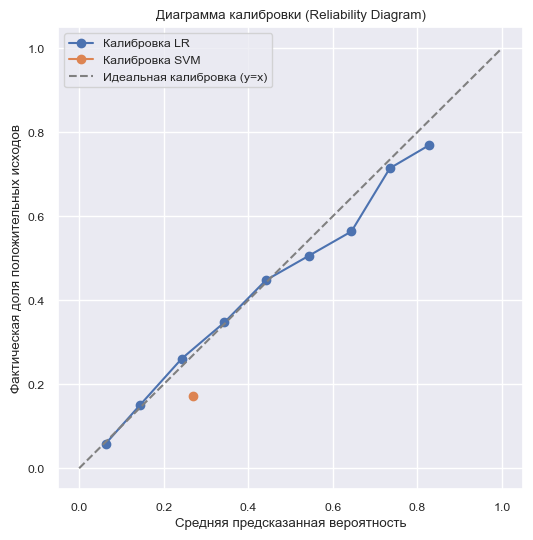

In [33]:
# Функция сигмоиды для отображения (-np.inf, np.inf) в (0, 1)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Вероятности для SVM
y_proba_test_svm = sigmoid(y_scores_test_svm)
lr_prob_true, lr_prob_pred = calibration_curve(y_test, y_proba_test, n_bins=10)
svm_prob_true, svm_prob_pred = calibration_curve(y_test, y_proba_test_svm, n_bins=10)

# Шаг 3: строим график
def draw_calib_curve(list):
    plt.figure(figsize=(6,6))
    for l in list:
        plt.plot(l[1], l[0], marker='o', label=l[2])

    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Идеальная калибровка (y=x)')
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Фактическая доля положительных исходов')
    plt.title('Диаграмма калибровки (Reliability Diagram)')
    plt.legend()
    plt.grid(True)
    plt.show()

draw_calib_curve([(lr_prob_true, lr_prob_pred, "Калибровка LR"),
                  (svm_prob_true, svm_prob_pred, "Калибровка SVM")])

- Модель логистической регрессии хорошо откалибрована.
- Логистическая регрессия на вероятностях более 0.5 ошибается в сторону положительного класса (демонстрируют излишнюю уверенность).
- SVM выдает все время вероятности в пределах одного бина, поэтому на диаграмме ей соответствует одна точка.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

#### 9.2 Применение методов калибровки
- Откалибруем модели логистической регрессии и SVM на калибровочной выборке на 5 фолдах:

In [34]:
cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Откалиброванный LR
lr_calibrated = CalibratedClassifierCV(FrozenEstimator(final_pipeline), 
                                       method='isotonic',
                                       cv=cv)
lr_calibrated.fit(X_calib, y_calib)

# Откалиброванный SVM
svm_calibrated = CalibratedClassifierCV(FrozenEstimator(final_svm_pipeline), 
                                       method='isotonic',
                                       cv=cv)
svm_calibrated.fit(X_calib, y_calib)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",FrozenEstimat..._state=42))]))
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('ct', ...), ('feature_eng', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<font color='green'> Отлично, что используется независимая выборка.</font>

#### 9.3 Сравнение моделей до и после калибровки

- Получим предсказания калиброванных моделей и построим калибровочную кривую:

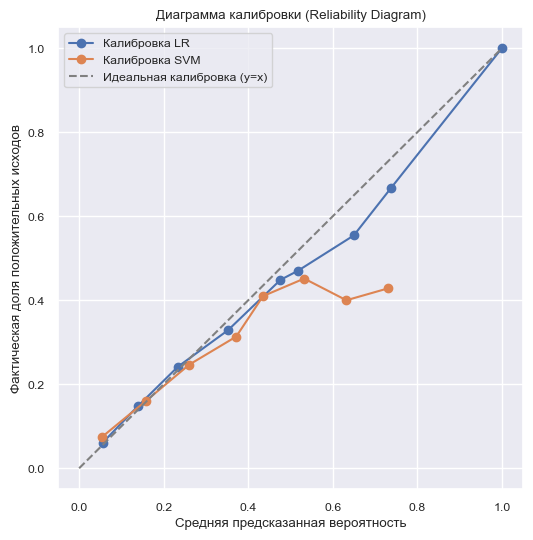

In [35]:
y_proba_test_calib = lr_calibrated.predict_proba(X_test)[:, 1]
y_proba_test_svm_calib = svm_calibrated.predict_proba(X_test)[:, 1]

lr_prob_calib_true, lr_prob_calib_pred = calibration_curve(y_test, y_proba_test_calib, n_bins=10)
svm_prob_calib_true, svm_prob_calib_pred = calibration_curve(y_test, y_proba_test_svm_calib, n_bins=10)

draw_calib_curve([(lr_prob_calib_true, lr_prob_calib_pred, "Калибровка LR"),
                  (svm_prob_calib_true, svm_prob_calib_pred, "Калибровка SVM")])

- На основании диаграммы калибровки можно видеть, что калибровка модели SVM улучшилась.
- Для оценки качества калибровки логистической регрессии и более детального анализа качества откалиброванной модели SVM необходимо оценить метрики Бриера, MCE, ECE.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 10. Оценка качества калибровки

#### 10.1 Вычисление метрик калибровки
- Получим оценки для обеих моделей до и после калибровки:

In [36]:
# Функция, добавляющая к набору метрик MCE и ECE
def calc_all_metrics(y_true, y_prob, n_bins=10, prefix=''):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    max_error = 0
    n = len(y_true)
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        if i == n_bins - 1:
            mask = (y_prob <= bin_upper) & (y_prob >= bin_lower)
        else:
            mask = (y_prob < bin_upper) & (y_prob >= bin_lower)
        bin_size = np.sum(mask)
        if np.sum(mask) > 0:
            bin_conf = np.mean(y_prob[mask])
            bin_acc = np.mean(y_true[mask])
            ece += np.abs(bin_conf - bin_acc) * bin_size
            max_error = max(max_error, np.abs(bin_conf - bin_acc))
    
    prev_metrics = calc_metrics(y_true, y_prob, prefix=prefix)
    prev_metrics.update({(prefix + 'mce'): max_error, 
                                 (prefix + 'ece'): ece / n})
    return prev_metrics

lr_precalib_metrics = calc_all_metrics(y_test, y_proba_test)
svm_precalib_metrics = calc_all_metrics(y_test, y_proba_test_svm)
lr_calib_metrics = calc_all_metrics(y_test, y_proba_test_calib)
svm_calib_metrics = calc_all_metrics(y_test, y_proba_test_svm_calib)

display(pd.DataFrame({'LR': lr_precalib_metrics,
                      'LR Calib.': lr_calib_metrics,
                      'SVM': svm_precalib_metrics,
                      'SVM Calib.': svm_calib_metrics}))


,LR,LR Calib.,SVM,SVM Calib.
accuracy,0.832400,0.830200,0.827900,0.827000
f1,0.185617,0.250000,0.000000,0.039956
average_precision,0.391501,0.375801,0.292777,0.284426
precision,0.566766,0.521179,0.000000,0.444444
recall,0.110982,0.164439,0.000000,0.020918
neg_log_loss,-0.402563,-0.403897,-0.485345,-0.436798
brier_loss,0.125299,0.125719,0.151853,0.135056
mce,0.080305,0.095405,0.096834,0.303171
ece,0.008573,0.012021,0.096834,0.015076


#### 10.2 Сравнение моделей до и после калибровки
- Построим кривые калибровки для каждой модели до и после калибровки:

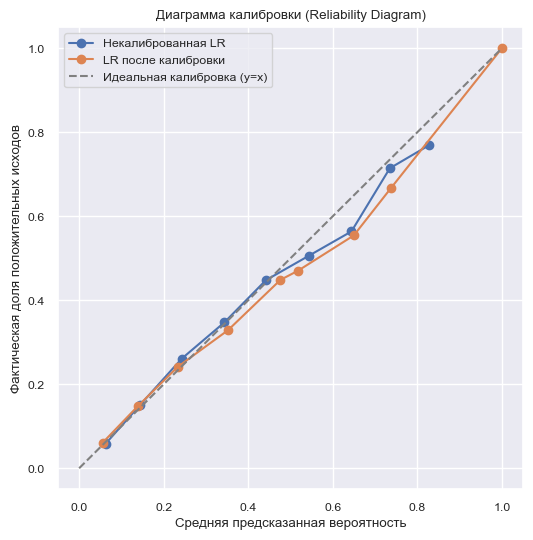

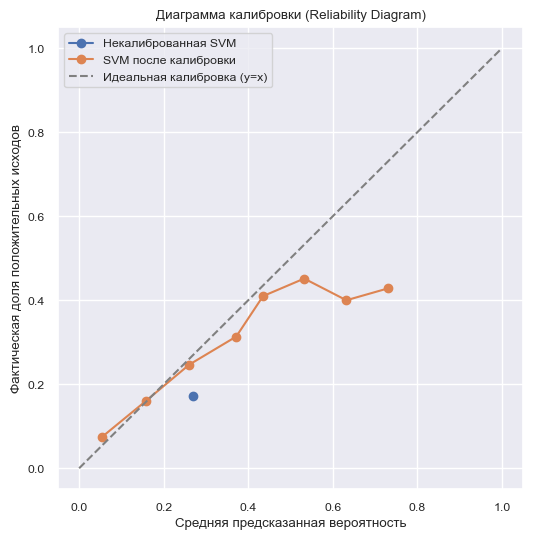

In [37]:
draw_calib_curve([(lr_prob_true, lr_prob_pred, "Некалиброванная LR"),
                  (lr_prob_calib_true, lr_prob_calib_pred, "LR после калибровки")])
draw_calib_curve([(svm_prob_true, svm_prob_pred, "Некалиброванная SVM"),
                  (svm_prob_calib_true, svm_prob_calib_pred, "SVM после калибровки")])

#### 10.3. Выводы
- У модели логистической регрессии после калибровки ухудшились метрики максимальной ошибки MCE и средней ошибки ECE. Оценка Бриера осталась на том же уровне.
- У модели SVM калибровка значительно ухудшила оценку MCE, улучшила ECE, оценка Бриера также улучшилась, но в меньшей степени.
- Также можно заметить, что у обеих моделей после калибровки выросла метрика F1 за счет роста recall при небольшом уменьшении precision.
- Модель SVM после калибровки стала выдавать более осмысленные предсказания, но все равно она непригодна для продакшена, так как прогнозируемые ею вероятности слишком далеки от реальных частот.
- Для продакшена следует выбрать некалиброванную модель логистической регрессии.

<span style="color: blue; font-weight: bold">Комментарий ревьюера : </span> ✔️\
<span style="color: green"> 👍</span>

## 11. Финальный отчёт и выводы

### 11.1 Таблицы результатов
- Оценки всех моделей относительно базовой:

In [38]:
dummy_metrics_clip = {k.removeprefix("test_"): v 
                      for k, v in dummy_metrics.items() if k.startswith("test_")}
display(pd.DataFrame({'Dummy': dummy_metrics_clip,
                      'LR': lr_precalib_metrics,
                      'LR Calib.': lr_calib_metrics,
                      'SVM': svm_precalib_metrics,
                      'SVM Calib.': svm_calib_metrics}))

,Dummy,LR,LR Calib.,SVM,SVM Calib.
accuracy,0.827933,0.832400,0.830200,0.827900,0.827000
f1,0.000000,0.185617,0.250000,0.000000,0.039956
average_precision,0.172067,0.391501,0.375801,0.292777,0.284426
precision,0.000000,0.566766,0.521179,0.000000,0.444444
recall,0.000000,0.110982,0.164439,0.000000,0.020918
neg_log_loss,-0.459148,-0.402563,-0.403897,-0.485345,-0.436798
brier_loss,NaN,0.125299,0.125719,0.151853,0.135056
mce,NaN,0.080305,0.095405,0.096834,0.303171
ece,NaN,0.008573,0.012021,0.096834,0.015076


- Характеристики финальной модели `LogisticRegresion`:

In [39]:
display(lr_best_params)

{'classify__C': 0.1,
 'classify__l1_ratio': 0.5,
 'classify__penalty': 'elasticnet',
 'classify__solver': 'saga'}

- Топ-5 самых важных признаков:

In [40]:
display(df_coef[:][:5].style.background_gradient(cmap='viridis'))

,coef,Признак
0,2.663855,cat_target__site_id
1,2.493454,cat_target__app_id
2,1.704243,cat_target__C17
3,0.968766,cat_target__C14
4,0.750087,cat_target__C20


### 11.2 Финальные выводы
- Для обучения модели классификации был предоставлен датасет из 50000 записей. Он был разделен на обучающую, калибрационную и тестовую выборки в отношении 3:1:1.
- На этапе исследовательского анализа данных были исследованы распределения признаков и целевой переменной. По результатам анализа корреляции признаков с целевой переменной были отобраны наиболее важные признаки.
- Дополнительные признаки для обучения были отобраны при помощи фильтрационных методов и применения методов-обёрток.
- На обучающей выборке были обучены модели `DummyClassifier` (базовая), `LogisticRegression` и `SVC` с параметрами по умолчанию. На кросс-валидации обе модели показали лучшие результаты, чем базовая, однако после обучения на всей обучающей выборке модель SVM стала предсказывать только один класс и сравнялась с базовой.
- Для моделей `LogisticRegression` и `SVC` был выполнен подбор гиперпараметров при помощи `GridSearch` и кросс-валидации. В результате лучшей оказалась модель `LogisticRegression` с параметрами `C`=0.1, `ll_ratio`=0.5, `penalty`=`elasticnet`, `solver`=`'saga'`.
- Для моделей `LogisticRegression` и `SVC` была выполнена калибровка с использованием калибровочной выборки. Модель `SVC` стала выдавать более похоже на реальность предсказания, однако предсказываемые вероятности слишком сильно отличаются от реальных частот. Калибровка модели логистической регрессии немного ухудшилась.
- Выбранная некалиброванная модель `LogisicRegression` показывает лучшие результаты, чем базовая по всем метрикам. Основная метрика PR-AUC у выбранной модели в 2.2 раза лучше, чем у `DummyClassifier`.
- На основе анализа весов модели логистической регрессии были выявлены наиболее важные признаки. Более других на вероятность клика влияют признаки идентификаторов приложения и сайта, а также анонимизированные признаки `C17`, `C14`, `C20`. Эти же признаки показывали высокий уровень корреляции с целевой переменной.
- Согласно метрикам Brier, MCE, ECE модель откалибрована хорошо, однако на вероятностях >= 0.4 она дает немного более оптимистичные предсказания, чем реальная частота положительного класса.
- Модель готова к использованию в продакшене с учетом упомянутых особенностей калибровки.

### 11.3 Рекомендации
- Диаграмма корреляций признаков с тестовой переменной показала наличие зависимостей внутри группы признаков `C14`-`C21`. Можно попробовать заменить отдельные наборы признаков из этой подгруппы их комбинацией (произведением, отношением и проч.).

<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Очень приятно видеть вывод в конце проекта!\
Приведены ответы на главные вопросы проекта.</font>

## 12. Сохранение модели для продакшена

### 12.1 Сохранение артефактов
- Сохраним калиброванный пайплайн логистической регрессии и отдельно - пайплйн для предобработки:

In [41]:
COMPLETE_FILE_NAME = "cte_predict.joblib"
PP_FILE_NAME = "cte_predict_pp.joblib"

pp_pipeline = final_pipeline.named_steps['preprocess']

# Сохраняем полный пайплайн на диск
joblib.dump(final_pipeline, COMPLETE_FILE_NAME)

# Сохраняем пайплайн предобработки на диск
joblib.dump(pp_pipeline, PP_FILE_NAME)

['cte_predict_pp.joblib']

### 12.2 Проверка работоспособности сохраненных артефактов
- Загрузим и проверим сохраненные пайплайны:

In [42]:
# Проверка
load_pipeline = joblib.load(COMPLETE_FILE_NAME)
y_test_pred_load = load_pipeline.predict_proba(X_test)[:, 1]

diff = np.abs(y_proba_test - y_test_pred_load).sum()
if diff == 0.0:
    print("Пайплайн сохранен, проверка прошла успешно.")
else:
    print("Ошибка: ", diff)

Пайплайн сохранен, проверка прошла успешно.


<font color='blue'><b>Комментарий ревьюера : </b></font> ✔️\
<font color='green'> Артефакты сохранены.</font>

<font color='blue'><b>Итоговый комментарий ревьюера</b></font>\
<font color='green'>Андрей, хороший проект получился!
Большое спасибо за проделанную работу. Видно, что приложено много усилий.
Выводы и рассуждения получились содержательными, их было интересно читать.
</font>

<font color='steelblue'>Над проектом ещё стоит поработать - есть рекомендации по дополнению некоторых твоих шагов проекта. Такие рекомендации я отметил жёлтыми комментариями. Будет здорово, если ты учтёшь их - так проект станет структурно и содержательно более совершенным.

Также в работе есть критические замечания. К этим замечаниям я оставил пояснительные комментарии красного цвета, в которых перечислил возможные варианты дальнейших действий. Уверен, ты быстро с этим управишься:)

Если о том, что нужно сделать в рамках комментариев, будут возникать вопросы - оставь их, пожалуйста, в комментариях, и я отвечу на них во время следующего ревью.

Также буду рад ответить на любые твои вопросы по проекту или на какие-либо другие, если они у тебя имеются - оставь их в комментариях, и я постараюсь ответить:)</font>

<font color='blue'><b>Жду твой проект на повторном ревью. До встречи :) </b></font>

</span><br><span style="color: purple; font-weight: bold">Комментарий студента.</span><br>
<span style="color: darkorange">Павел, подскажи пожалуйста, с чем связано такое поведение модели `SVC` на этих данных? При кросс-валидации она выдаёт приличные показатели, а после обучения на всей обучающей выборке схлопывается в один класс. Искал, где может быть ошибка в коде - кажется, все правильно.
<br>
Благодарю за ссылку на блок Дьяконова.</span>